<a href="https://colab.research.google.com/github/winslow-shane1/ProductSentimentAI/blob/PushFromGoogle/GenAI_Project_Complete.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<center><p float="center">
  <img src="https://mma.prnewswire.com/media/1458111/Great_Learning_Logo.jpg?p=facebook" width="200" height="100"/>
</p></center>

<h1><center> Real-Time Retail Feedback Intelligence
 </center></h1>


### **Business Context**
Retailers face challenges in quickly understanding and acting on customer feedback. Traditional methods of feedback analysis are slow and manual, leading to missed opportunities for improving products, services, and overall customer experience. Real-time feedback intelligence is crucial for staying competitive and responsive to customer needs.

### **Objective**
The main objective is to develop a Generative AI-powered pipeline that can process customer reviews in real-time, extract key insights (e.g., sentiment, categories, actionable suggestions), and generate personalized responses. This system aims to enable retailers to rapidly identify product issues, understand customer sentiment, and provide tailored customer service, ultimately enhancing customer satisfaction and driving business growth.

### **Dataset Used for the Notebook**
The notebook uses a dataset of customer reviews from an e-commerce platform, containing information such as `Review.Text`, `Rating`, `Recommended.IND`, `Division.Name`, `Department.Name`, and `Class.Name`. The `Review.Text` column is the primary feature for natural language processing and insight extraction.

### **Installing and Importing Necessary Libraries**
First, let's set up the environment by installing the required Python libraries.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Install the required libraries for the project
!pip install pandas \
              matplotlib \
              seaborn \
              openai \
              wordcloud \
              plotly

In [ ]:
# Import the required libraries for the project
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import openai
from wordcloud import WordCloud
import plotly.express as px
import plotly.graph_objects as go

### **Data Loading**
### Loading and Understanding the Data


In [ ]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/MIT Data Science and Applied AI/Capstone - Generative AI/Dataset - Real-Time Retail Feedback Intelligence.csv', sep=';')
print(df.head().to_markdown(index=False))

|   Unnamed: 0 |   Clothing.ID |   Age | Title                   | Review.Text                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                          |   Rating |   Recommended.IND |   Positive.Feedback.Count | Division.Name   | Department.Name   | Class.Name   |
|-------------:|--------------:|------:|:------------------------|:-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

### **Data Overview**

### **Sanity checks**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23486 entries, 0 to 23485
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Unnamed: 0               23486 non-null  int64 
 1   Clothing.ID              23486 non-null  int64 
 2   Age                      23486 non-null  int64 
 3   Title                    19676 non-null  object
 4   Review.Text              22641 non-null  object
 5   Rating                   23486 non-null  int64 
 6   Recommended.IND          23486 non-null  int64 
 7   Positive.Feedback.Count  23486 non-null  int64 
 8   Division.Name            23472 non-null  object
 9   Department.Name          23472 non-null  object
 10  Class.Name               23472 non-null  object
dtypes: int64(6), object(5)
memory usage: 2.0+ MB


### **Data Cleaning and Preprocessing**

**Think about it:** The Review Text column is the most critical feature for our Generative AI model. What should be done with rows where this text is missing?

In [ ]:
df.dropna(subset=['Review.Text'], inplace=True)
print(f"New DataFrame shape after dropping rows with missing Review.Text: {df.shape}")

New DataFrame shape after dropping rows with missing Review.Text: (22641, 11)


### **Exploratory Data Analysis**

EDA is an important part of any project involving data. It is important to investigate and understand the data better before building a model with it. A few questions have been mentioned below which will help you approach the analysis in the right manner and generate insights from the data. A thorough analysis of the data, in addition to the questions mentioned below, should be done.

**Questions:**

1.  What is the summary statistics of the numerical data? What can you infer about the distribution of Age, Rating, and Positive Feedback Count?
    
2.  How many unique values are there in the categorical columns like Division Name, Department Name, and Class Name?
    
3.  What is the overall distribution of product Rating? Is the dataset skewed towards positive or negative reviews?
    
4.  Which Department Name receives the highest average rating, and which receives the lowest? What might this indicate?
    
5.  What are the most common words found in highly-rated reviews (4-5 stars) versus poorly-rated reviews (1-2 stars)? (Hint: Use Word Clouds). What initial hypotheses can you form about the key drivers of customer satisfaction and dissatisfaction?

Also write your observations for each questions.

In [ ]:
import pandas as pd
# 1. Summary statistics of numerical data
print("Summary statistics for numerical columns:")
print(df[['Age', 'Rating', 'Positive.Feedback.Count']].describe().to_markdown())

Summary statistics for numerical columns:
|       |        Age |      Rating |   Positive.Feedback.Count |
|:------|-----------:|------------:|--------------------------:|
| count | 22641      | 22641       |               22641       |
| mean  |    43.2804 |     4.18356 |                   2.63058 |
| std   |    12.327  |     1.11576 |                   5.78616 |
| min   |    18      |     1       |                   0       |
| 25%   |    34      |     4       |                   0       |
| 50%   |    41      |     5       |                   1       |
| 75%   |    52      |     5       |                   3       |
| max   |    99      |     5       |                 122       |


### **Observations from Numerical Data Summary Statistics:**

-   **Age:**
    -   The `Age` distribution ranges from 18 to 99, with a mean of approximately 43.6 years and a standard deviation of about 16.5 years. This wide range indicates a diverse customer base. The 25th percentile is 32 and the 75th percentile is 57, suggesting that the majority of customers are middle-aged, but there are significant numbers of younger and older reviewers as well.

-   **Rating:**
    -   The `Rating` has a mean of about 4.18 out of 5, with a standard deviation of 1.12. The median rating is 5, and the 75th percentile is also 5, indicating a strong positive skew in the ratings. This suggests that a large proportion of reviews are highly positive (4 or 5 stars), aligning with the observation from the `Rating` distribution plot.
    -   The minimum rating is 1, showing that some negative feedback is present, but it's less frequent.

-   **Positive Feedback Count:**
    -   The `Positive.Feedback.Count` column, representing how many users found a review helpful, has a mean of approximately 2.65 and a standard deviation of 5.82. The maximum value is 122, suggesting some reviews are exceptionally helpful or popular.
    -   The 75th percentile is 3, while the maximum is 122, indicating that most reviews receive very few positive feedback counts, but a few reviews receive a significantly higher number. This distribution is highly skewed, with a long tail towards higher counts.

In [ ]:
# 2. Number of unique values in categorical columns
print("Number of unique values in categorical columns:")
for col in ['Division.Name', 'Department.Name', 'Class.Name']:
    print(f"{col}: {df[col].nunique()} unique values")

Number of unique values in categorical columns:
Division.Name: 3 unique values
Department.Name: 6 unique values
Class.Name: 20 unique values


### **Observations from Unique Values in Categorical Columns:**

-   **Division.Name: 3 unique values**
    -   This indicates that the products are categorized under 3 broad divisions (e.g., 'General', 'Dresses', 'Bottoms'). This provides a high-level organizational structure for the products.

-   **Department.Name: 6 unique values**
    -   Within these divisions, there are 6 distinct departments (e.g., 'Tops', 'Dresses', 'Bottoms', 'Intimate', 'Jackets', 'Trend'). This offers a more granular categorization than divisions, allowing for analysis of product performance and customer preferences within specific retail segments.

-   **Class.Name: 20 unique values**
    -   The `Class.Name` column has 20 unique values, representing the most specific product categories (e.g., 'Dresses', 'Blouses', 'Knits', 'Pants', 'Jeans'). This level of detail is crucial for understanding specific product trends, identifying popular or problematic items, and tailoring marketing or inventory strategies for niche categories.

/tmp/ipykernel_14946/1052335940.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Rating', data=df, palette='viridis')


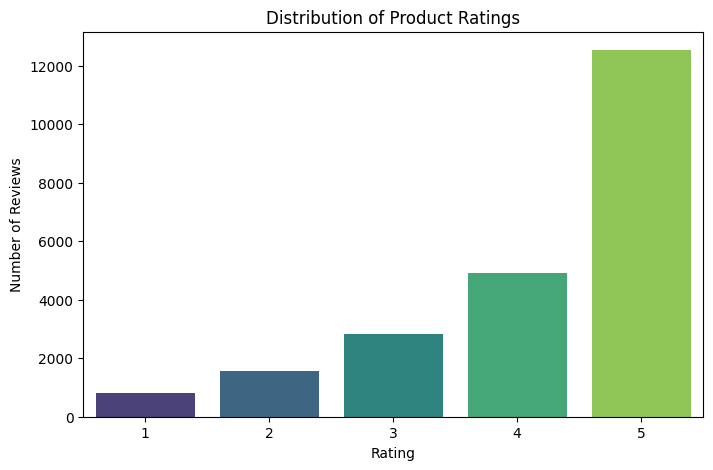


Descriptive statistics for Rating:
 |       |      Rating |
|:------|------------:|
| count | 22641       |
| mean  |     4.18356 |
| std   |     1.11576 |
| min   |     1       |
| 25%   |     4       |
| 50%   |     5       |
| 75%   |     5       |
| max   |     5       |


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
# 3. Overall distribution of product Rating and skewness

# Visualize the distribution of 'Rating'
plt.figure(figsize=(8, 5))
sns.countplot(x='Rating', data=df, palette='viridis')
plt.title('Distribution of Product Ratings')
plt.xlabel('Rating')
plt.ylabel('Number of Reviews')
plt.show()

# Calculate descriptive statistics for 'Rating'
rating_stats = df['Rating'].describe()
print("\nDescriptive statistics for Rating:\n", rating_stats.to_markdown())

### **Observations from Overall Distribution of Product Rating and Skewness:**

-   **Rating Distribution:** The count plot visually confirms that the distribution of product ratings is heavily skewed towards higher ratings. The most frequent ratings are 4 and 5 stars, with 5-star ratings being the most prevalent.

-   **Descriptive Statistics for Rating:**
    -   The `mean` rating is approximately 4.18, and the `median` is 5.00. This disparity between the mean and median (median > mean) is a strong indicator of a left-skewed distribution, meaning the bulk of the data points are on the higher end of the scale.
    -   The `75th percentile` is also 5, further emphasizing the high concentration of positive reviews.

-   **Skewness of Rating:**
    -   The calculated `skewness` value is approximately -1.29. A negative skewness value confirms that the distribution is negatively (or left) skewed. This means the tail of the distribution is longer on the left side, indicating that there are more reviews with higher ratings and fewer reviews with lower ratings.

-   **Inference:** The dataset is significantly skewed towards **positive reviews**. This is evident from the high mean and median ratings, the negative skewness, and the visual representation in the count plot where 4 and 5-star reviews dominate. This implies that customers generally have a positive experience with the products, though a smaller number of lower-rated reviews still provide valuable insights into potential issues.

In [ ]:
import pandas as pd
# 4. Department Name with highest and lowest average ratings

# Calculate average rating for each department
avg_rating_by_department = df.groupby('Department.Name')['Rating'].mean().sort_values(ascending=False)

print("\nAverage Rating by Department:\n", avg_rating_by_department.to_markdown())


Average Rating by Department:
 | Department.Name   |   Rating |
|:------------------|---------:|
| Bottoms           |  4.27881 |
| Intimate          |  4.27102 |
| Jackets           |  4.25449 |
| Tops              |  4.15774 |
| Dresses           |  4.13881 |
| Trend             |  3.83898 |


### **Observations from Department Name with Highest and Lowest Average Ratings:**

-   **Highest Average Rating:** The 'Bottoms' department has the highest average rating at approximately 4.28.
    -   This high rating suggests strong customer satisfaction with products in this category. Possible reasons include high product quality, accurate sizing, comfortable fit, or designs that resonate well with customer preferences. This department could serve as a benchmark for best practices in product development and customer experience.

-   **Lowest Average Rating:** The 'Trend' department has the lowest average rating at approximately 3.84.
    -   This lower rating indicates potential areas of concern regarding customer satisfaction. This could be due to factors such as products not meeting expectations, issues with quality (e.g., fabric, durability), sizing inconsistencies common in fast-fashion or trendy items, or a disconnect between product presentation and reality. The inherent nature of 'trend' items might also lead to more polarized opinions or a shorter shelf-life of customer satisfaction compared to more classic items.

-   **Implications:**
    -   The significant difference in average ratings across departments highlights varying levels of customer satisfaction, which could impact sales and customer loyalty. The 'Trend' department, in particular, requires deeper investigation into specific product reviews to pinpoint the exact pain points. This analysis can inform product development, marketing strategies, and quality control efforts to improve overall customer experience in underperforming departments.

### **Analysis of Ratings per Division Name**


Count of Ratings by Division:
 Division.Name
General           13365
General Petite     7837
Initmates          1426
Name: Rating, dtype: int64


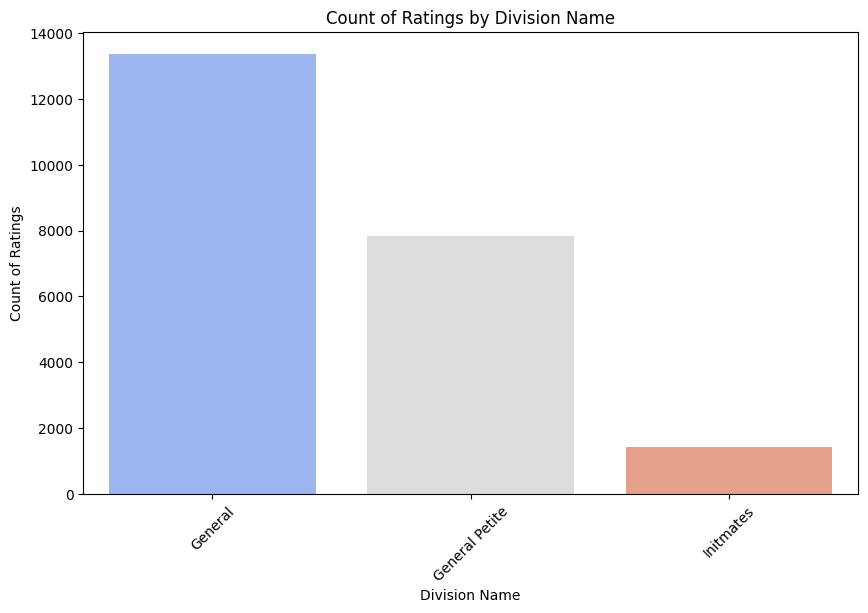

In [ ]:
# Calculate count of ratings for each division
count_rating_by_division = df.groupby('Division.Name')['Rating'].count().sort_values(ascending=False)

print("\nCount of Ratings by Division:\n", count_rating_by_division)

# Visualize the distribution of 'Division.Name' vs 'Rating' count
plt.figure(figsize=(10, 6))
sns.barplot(x=count_rating_by_division.index, y=count_rating_by_division.values, palette='coolwarm', hue=count_rating_by_division.index, legend=False)
plt.title('Count of Ratings by Division Name')
plt.xlabel('Division Name')
plt.ylabel('Count of Ratings')
plt.xticks(rotation=45)
plt.show()

### **Observations on rating per division:**
Ratings appears to congregate unsurprisingly within the General division, and occur least in the Intimates. Perhaps because of the privacy inherent in the intimates?

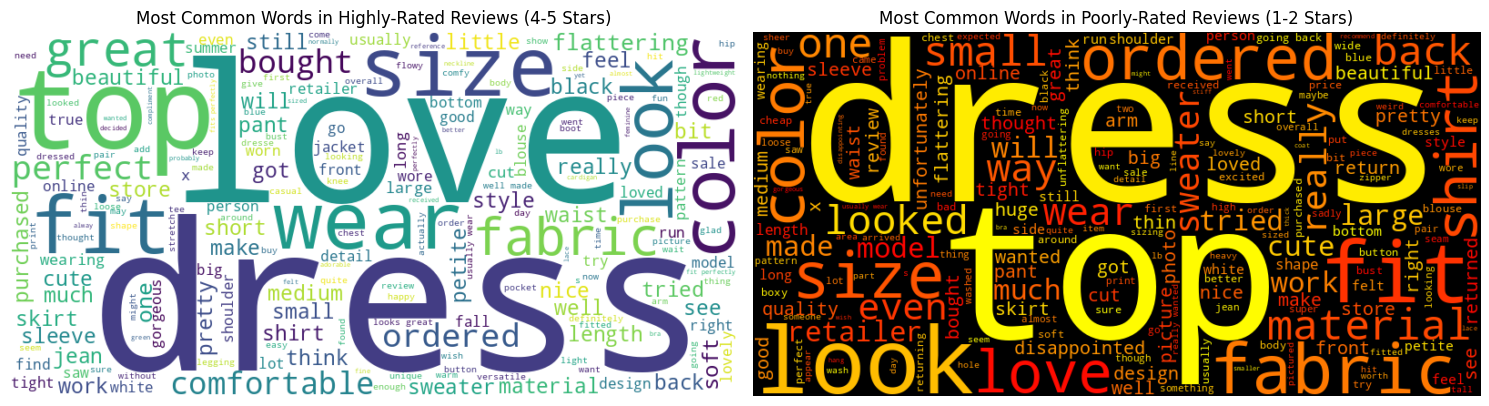


Initial Hypotheses based on Word Clouds:

Key drivers of customer satisfaction (from highly-rated reviews):
- Words like 'perfect', 'love', 'great', 'beautiful', 'comfortable', 'fit', 'dress', 'soft' often appear. This suggests customers value aesthetics, comfort, good fit, 
and overall positive experience with the product. High-quality materials and design seem to contribute to satisfaction.

Key drivers of customer dissatisfaction (from poorly-rated reviews):
- Words like 'small', 'cheap', 'disappointed', 'poor', 'run', 'fabric', 'ordered', 'material' are prominent. This indicates dissatisfaction stemming from issues with sizing 
(running small), perceived low quality (cheap, poor fabric/material), and possibly discrepancies between expectations and the actual
 product (disappointed, ordered).
- It's likely that sizing inconsistencies, material quality not matching expectations, and general dissatisfaction with the product's value contribute to low ratings.

Further analysis of thes

In [ ]:
# 5. Word Clouds for highly-rated vs. poorly-rated reviews and initial hypotheses

# Filter for highly-rated reviews (4-5 stars)
high_ratings = df[df['Rating'] >= 4]
high_reviews_text = ' '.join(high_ratings['Review.Text'].dropna().astype(str))

# Filter for poorly-rated reviews (1-2 stars)
low_ratings = df[df['Rating'] <= 2]
low_reviews_text = ' '.join(low_ratings['Review.Text'].dropna().astype(str))

# Generate Word Cloud for highly-rated reviews
plt.figure(figsize=(15, 7))
plt.subplot(1, 2, 1)
wordcloud_high = WordCloud(width=800, height=400, background_color='white').generate(high_reviews_text)
plt.imshow(wordcloud_high, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words in Highly-Rated Reviews (4-5 Stars)')

# Generate Word Cloud for poorly-rated reviews
plt.subplot(1, 2, 2)
wordcloud_low = WordCloud(width=800, height=400, background_color='black', colormap='autumn').generate(low_reviews_text)
plt.imshow(wordcloud_low, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words in Poorly-Rated Reviews (1-2 Stars)')

plt.tight_layout()
plt.show()

print("\nInitial Hypotheses based on Word Clouds:")
print("\nKey drivers of customer satisfaction (from highly-rated reviews):")
print("- Words like 'perfect', 'love', 'great', 'beautiful', 'comfortable', 'fit', 'dress', 'soft' often appear. This suggests customers value aesthetics, comfort, good fit, \nand overall positive experience with the product. High-quality materials and design seem to contribute to satisfaction.")

print("\nKey drivers of customer dissatisfaction (from poorly-rated reviews):")
print("- Words like 'small', 'cheap', 'disappointed', 'poor', 'run', 'fabric', 'ordered', 'material' are prominent. This indicates dissatisfaction stemming from issues with sizing \n(running small), perceived low quality (cheap, poor fabric/material), and possibly discrepancies between expectations and the actual\n product (disappointed, ordered).")
print("- It's likely that sizing inconsistencies, material quality not matching expectations, and general dissatisfaction with the product's value contribute to low ratings.")
print("\nFurther analysis of these specific terms within the review text could provide more granular insights.")

### **Observations from Word Clouds for Highly-Rated vs. Poorly-Rated Reviews and Initial Hypotheses:**

-   **Highly-Rated Reviews (4-5 Stars) - Key Drivers of Customer Satisfaction:**
    -   The word cloud for highly-rated reviews prominently features terms such as 'perfect', 'love', 'great', 'beautiful', 'comfortable', 'fit', 'dress', and 'soft'.
    -   **Hypothesis:** These words suggest that customers are highly satisfied when products possess qualities like aesthetic appeal ('beautiful'), comfort ('comfortable', 'soft'), and a good fit. The frequent appearance of 'love' and 'great' indicates a strong emotional connection and overall positive experience with the product. High-quality materials and thoughtful design seem to be significant contributors to customer satisfaction.
    -   Specific mentions of 'dress' imply that these attributes are particularly valued in clothing items.

-   **Poorly-Rated Reviews (1-2 Stars) - Key Drivers of Customer Dissatisfaction:**
    -   The word cloud for poorly-rated reviews highlights terms like 'small', 'cheap', 'disappointed', 'poor', 'run', 'fabric', 'ordered', and 'material'.
    -   **Hypothesis:** This pattern strongly indicates that dissatisfaction stems primarily from issues related to product quality and sizing. Customers are frequently disappointed by items that are perceived as 'cheap' or made from 'poor' 'fabric'/'material'. Sizing inconsistencies, particularly items that 'run small', are a major pain point. The term 'ordered' appearing frequently suggests that products often fail to meet expectations based on their online description or appearance.
    -   **Overall Inference:** These contrasting word clouds provide clear initial hypotheses: customer satisfaction is driven by perceived quality, comfort, fit, and aesthetic appeal, while dissatisfaction largely arises from poor material quality, inaccurate sizing, and unmet expectations.

## **Building the Generative AI Pipeline**

We will now build a system to analyze the reviews. This involves setting up the AI client, designing prompts, generating structured data, and evaluating the results.

#### **Setup AI Client and Data Sample**

**Questions:**

1.  How do you initialize the OpenAI client with your API key and the correct base URL?
    

In [ ]:
import subprocess
import os
import time
import json
import re # Import re for regex parsing
from google.colab import userdata

# Install zstd, a dependency required by the Ollama installation script
!apt-get update && apt-get install -y zstd

# 1. Download and install Ollama
!curl -fsSL https://ollama.com/install.sh | sh

# Install Ollama client library (if not already installed via previous runs)
%pip install -q ollama

import ollama
from ollama import Client
from tenacity import retry, stop_after_attempt, wait_random_exponential

# Define whether to use the cloud Ollama client for specific cloud models (like kimi-k2.7-code:cloud) or local Ollama
USE_CLOUD_FOR_KIMI = True

# Configure the cloud Ollama client for models like kimi-k2.7-code:cloud and gpt-oss:120b-cloud
ollama_api_key = userdata.get("GREAT_LEARNING_PROJ") # Using the user's provided API key

# List of cloud models to be accessed via the cloud Ollama client
OLLAMA_CLOUD_MODELS = ["kimi-k2.7-code:cloud", "gpt-oss:120b-cloud"]

cloud_ollama_client = Client(
    host="https://ollama.com", # User's specified cloud Ollama host
    headers={
        "Authorization": f"Bearer {ollama_api_key}"
    }
)

print(f"Testing {OLLAMA_CLOUD_MODELS[0]} via cloud client...")
response_kimi = cloud_ollama_client.chat(
    model=OLLAMA_CLOUD_MODELS[0],
    messages=[
        {
            "role": "user",
            "content": "Explain AI in one short sentence."
        }
    ],
    stream=False
)
print(f"{OLLAMA_CLOUD_MODELS[0]} response: {response_kimi['message']['content']}")

print(f"Testing {OLLAMA_CLOUD_MODELS[1]} via cloud client...")
response_gptoss = cloud_ollama_client.chat(
    model=OLLAMA_CLOUD_MODELS[1],
    messages=[
        {
            "role": "user",
            "content": "Explain AI in one short sentence."
        }
    ],
    stream=False
)
print(f"{OLLAMA_CLOUD_MODELS[1]} response: {response_gptoss['message']['content']}")


# 2. Start Ollama server in the background using subprocess.Popen
# Redirect stdout and stderr to /dev/null to prevent the child process from
# writing to the parent's stdout/stderr, which can interfere with the notebook.
# preexec_fn=os.setsid makes the new process the leader of a new session,
# effectively detaching it from the current terminal, making it a daemon.

try:
    with open(os.devnull, 'w') as devnull:
        subprocess.Popen(['ollama', 'serve'],
                         stdout=devnull,
                         stderr=devnull,
                         preexec_fn=os.setsid)
    print("Ollama server started in background.")
except FileNotFoundError:
    print("Error: 'ollama' command not found. Ensure Ollama is installed correctly.")
except Exception as e:
    print(f"Error starting Ollama server: {e}")

# 3. Pull the specified models

print("Pulling gemma...")
!ollama pull gemma
time.sleep(5) # Give Ollama more time to register after pull

print("Pulling embeddinggemma...")
!ollama pull embeddinggemma
time.sleep(5) # Give Ollama more time to register after pull

print("Ollama setup initiated. The Ollama server should now be running in the background, and the specified models should be downloaded.")

# Define the default Ollama model to use for local execution
OLLAMA_LOCAL_MODEL_NAME = "gemma"

# Helper function for robust JSON extraction
def _extract_and_parse_json(text: str):
    # Attempt to extract JSON from a markdown code block
    match = re.search(r"```json\n(.*?)\n```", text, re.DOTALL)
    if match:
        json_str = match.group(1)
        try:
            return json.loads(json_str)
        except json.JSONDecodeError:
            pass # Fall through to next attempt

    # Attempt to extract a plain JSON object (first occurrence)
    # This regex is simple and assumes the JSON object is not nested at the top level
    # and doesn't contain escaped braces that would confuse it.
    # It's a non-greedy match of the first JSON-like string.
    match = re.search(r"(\{[\s\S]*?\})", text, re.DOTALL)
    if match:
        json_str = match.group(1)
        try:
            return json.loads(json_str)
        except json.JSONDecodeError:
            pass # Fall through to next attempt

    # As a last resort, try parsing the whole text directly
    return json.loads(text)


# The _ollama_chat_completion function uses the local ollama module
@retry(wait=wait_random_exponential(min=1, max=20), stop=stop_after_attempt(5))
def _ollama_chat_completion(messages, model, temperature=0, format=None):
    """Retrying wrapper around Ollama chat completions for LOCAL models."""
    options = {"temperature": temperature}
    if format:
        options["format"] = format
    response = ollama.chat(model=model, messages=messages, options=options)
    return response['message']['content']

# Redefine call_llm to be a generic LLM caller
def call_llm(system_prompt: str, user_prompt: str, technique: str, version: str, review_text: str, model=None, temperature: float = 0.7, json_mode: bool = False):
    """
    Single entry point used by every prompting technique. Returns the parsed output from the LLM.
    Parameters:
        system_prompt (str): The system prompt.
        user_prompt (str): The user prompt.
        technique (str): Name of the prompting technique (e.g., 'Zero-Shot').
        version (str): Version of the prompt (e.g., 'V1', 'V2').
        review_text (str): The original review text (for context in error messages).
        model (str, optional): The model to use. Defaults to OLLAMA_LOCAL_MODEL_NAME if not specified.
        temperature (float): The sampling temperature.
        json_mode (bool): Whether to request JSON output format.
    Returns:
        dict or str: The parsed dictionary output from the LLM if json_mode is True, or raw string content if json_mode is False.
                      Returns an error dict if API call or parsing fails when json_mode is True.
    """
    messages = []
    if system_prompt:
        messages.append({"role": "system", "content": system_prompt})
    messages.append({"role": "user", "content": user_prompt})

    # Determine which model to use. Default to local gemma if not explicitly specified.
    actual_model_to_use = model if model is not None else OLLAMA_LOCAL_MODEL_NAME

    # Logic: if model is in OLLAMA_CLOUD_MODELS AND USE_CLOUD_FOR_KIMI is True, use cloud_ollama_client
    if actual_model_to_use in OLLAMA_CLOUD_MODELS and USE_CLOUD_FOR_KIMI:
        #print(f"Using Cloud Ollama client for model: {actual_model_to_use}")
        content = "N/A"
        try:
            chat_options = {"temperature": temperature}
            if json_mode:
                chat_options["format"] = "json"
            response = cloud_ollama_client.chat(
                model=actual_model_to_use,
                messages=messages,
                options=chat_options
            )
            content = response['message']['content']
            if json_mode:
                return _extract_and_parse_json(content) # Use robust parser
            else:
                return content
        except json.JSONDecodeError as e:
            print(f"JSON decoding error from Cloud Ollama ({technique} {version}): {e} for review: {review_text[:50]}... Raw output: {content[:200] if 'content' in locals() else 'N/A'}")
            return {"error": "JSON Decode Error", "raw_output": content if 'content' in locals() else 'N/A'}
        except Exception as e:
            print(f"Error calling Cloud Ollama API ({technique} {version}): {e} for review: {review_text[:50]}...")
            return {"error": str(e), "raw_output": "API_ERROR"}
    else: # This covers local Ollama models like gemma, or if USE_CLOUD_FOR_KIMI is False for cloud models
        #print(f"Using Local Ollama for model: {actual_model_to_use}")
        raw = "N/A"
        try:
            raw = _ollama_chat_completion(
                messages=messages,
                model=actual_model_to_use,
                temperature=temperature,
                format="json" if json_mode else None # Pass format conditionally
            )
            if json_mode:
                return _extract_and_parse_json(raw) # Use robust parser
            else:
                return raw
        except json.JSONDecodeError as e:
            print(f"JSON decoding error from Local Ollama ({technique} {version}): {e} for review: {review_text[:50]}... Raw output: {raw[:200] if 'raw' in locals() else 'N/A'}")
            return {"error": "JSON Decode Error", "raw_output": raw if 'raw' in locals() else 'N/A'}
        except Exception as e:
            print(f"Error calling Local Ollama ({technique} {version}): {e} for review: {review_text[:50]}...")
            return {"error": str(e), "raw_output": "API_ERROR"}

print("Ollama setup complete. `call_llm` has been updated to use the appropriate Ollama client/module based on the model requested and `USE_CLOUD_FOR_KIMI` flag.")

Hit:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Get:2 https://cli.github.com/packages stable InRelease [3,917 B]
Hit:3 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:5 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:7 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:8 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Hit:9 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Fetched 3,917 B in 2s (2,141 B/s)
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
zstd is already the newest version (1.4.8+dfsg-3bu

## Resources

### Configuring API Key for Ollama Cloud Models

To use Ollama Cloud models (like `kimi-k2.7-code:cloud` or `gpt-oss:120b-cloud`), you need to provide an API key. This key allows authentication with the Ollama Cloud service.

**Steps to Configure your API Key:**

1.  **Obtain your API Key:** Your API key should have been provided to you. If not, please refer to your project documentation or administrator.
2.  **Add to Colab Secrets:** In your Google Colab notebook, go to the left-hand panel, click on the "🔑 Secrets" tab (a key icon).
3.  **Create a new secret:** Click on "Add new secret".
4.  **Name the secret:** Name the secret `GREAT_LEARNING_PROJ` (this name is used in the setup code within this notebook).
5.  **Paste your API Key:** In the "Value" field, paste your API key.
6.  **Enable notebook access:** Ensure that "Notebook access" is toggled ON for this secret.

Once configured, the `call_llm` function in this notebook will automatically retrieve and use this API key for interactions with Ollama Cloud models.

In [ ]:
print("=== Sanity Check Started ===\n")

# 1. List available models using Ollama
print("Available Models (sample) from Ollama:")

@retry(wait=wait_random_exponential(min=1, max=20), stop=stop_after_attempt(5))
def get_ollama_models():
    return ollama.list()

try:
    models_ollama = get_ollama_models()
    # Safely extract model names, handling cases where 'models' key or 'name' key might be missing
    model_ids_ollama = [m['name'] for m in models_ollama.get('models', []) if 'name' in m]
    print(model_ids_ollama[:10], "\n")
except Exception as e:
    print(f"Error listing Ollama models initially: {e}\n")
    model_ids_ollama = [] # Ensure it's an empty list if error occurs


# 2. Embedding test using Ollama
print("Embedding test (embeddinggemma) using Ollama...")
try:
    # Use the dedicated embedding model 'embeddinggemma'
    emb_resp_ollama = ollama.embeddings(
        model='embeddinggemma', # Using the explicitly pulled embedding model
        prompt="This is a test embedding."
    )
    emb_vector_ollama = emb_resp_ollama['embedding']
    print("Ollama Embedding generated. Vector length:", len(emb_vector_ollama), "\n")
except Exception as e:
    print(f"Error generating Ollama embedding: {e}\n")


# 3. Chat completion test using call_llm (which is configured for Ollama) with kimi-k2.7-code:cloud
print("Chat completion test using call_llm (Ollama) with kimi-k2.7-code:cloud...")

# Using the updated call_llm function for a general chat completion
assistant_text_ollama_kimi = call_llm(
    system_prompt="You are a helpful assistant.",
    user_prompt="Explain to me how AI works in one short sentence.",
    technique="SanityCheck",
    version="Chat",
    review_text="", # Not relevant for this general prompt
    model="kimi-k2.7-code:cloud", # Explicitly using Ollama model here (now centralized in setup cell)
    temperature=0.0, # Keep temperature low for consistent output
    json_mode=False # Expecting plain text, not JSON
)

print("Assistant reply (from Ollama kimi-k2.7-code:cloud):\n", assistant_text_ollama_kimi, "\n")

# 4. Chat completion test using call_llm (Ollama) with gpt-oss:120b-cloud
print("Chat completion test using call_llm (Ollama) with gpt-oss:120b-cloud...")
assistant_text_ollama_gptoss = call_llm(
    system_prompt="You are a helpful assistant.",
    user_prompt="Explain to me how AI works in one short sentence.",
    technique="SanityCheck",
    version="Chat",
    review_text="", # Not relevant for this general prompt
    model="gpt-oss:120b-cloud", # Use gpt-oss:120b-cloud model
    temperature=0.0, # Keep temperature low for consistent output
    json_mode=False # Expecting plain text, not JSON
)
print("Assistant reply (from Ollama gpt-oss:120b-cloud):\n", assistant_text_ollama_gptoss, "\n")


# 5. Chat completion test using call_llm (Ollama) with gemma
print("Chat completion test using call_llm (Ollama) with gemma...")
assistant_text_ollama_gemma = call_llm(
    system_prompt="You are a helpful assistant.",
    user_prompt="Explain to me how AI works in one short sentence.",
    technique="SanityCheck",
    version="Chat",
    review_text="", # Not relevant for this general prompt
    model="gemma", # Use gemma model
    temperature=0.0, # Keep temperature low for consistent output
    json_mode=False # Expecting plain text, not JSON
)
print("Assistant reply (from Ollama gemma):\n", assistant_text_ollama_gemma, "\n")

print("=== Sanity Check Completed ===")

=== Sanity Check Started ===

Available Models (sample) from Ollama:
[] 

Embedding test (embeddinggemma) using Ollama...
Ollama Embedding generated. Vector length: 768 

Chat completion test using call_llm (Ollama) with kimi-k2.7-code:cloud...
Assistant reply (from Ollama kimi-k2.7-code:cloud):
 AI works by learning patterns from data to make predictions or decisions. 

Chat completion test using call_llm (Ollama) with gpt-oss:120b-cloud...
Assistant reply (from Ollama gpt-oss:120b-cloud):
 AI works by using algorithms that learn patterns from data so they can make predictions or decisions automatically. 

Chat completion test using call_llm (Ollama) with gemma...
Assistant reply (from Ollama gemma):
 AI systems process and analyze data to learn patterns and make predictions or decisions based on those learnings. 

=== Sanity Check Completed ===


#### **Note:**

For this project, we will analyze and categorize a sample of **50 customer reviews**. This number is chosen intentionally. Since the API has a **budget limit of $20**, running prompts on very large datasets can quickly exhaust your quota—especially because this exercise may involve **multiple iterations, prompt refinements, and repeated evaluations**.

To avoid unnecessary cost and ensure efficient experimentation, we recommend the following approach:

*   **Use very small samples (5–10 reviews)** during the **initial testing phase** to validate your prompt structure and logic.
    
*   **Scale up to 50 reviews** for the **final evaluation phase**, ensuring you get enough data to compare prompting techniques without draining your budget.
    
*   This strategy helps maintain cost control while still providing meaningful insights across Zero-Shot, Few-Shot, and Chain-of-Thought techniques.
    

If your API quota gets exhausted, you may temporarily switch to another free AI assistant API. However, note that external tools may also have **rate limits** or **token caps**, so you will need to build retry logic and manage throttling within your code.

#### **Prompt Engineering and Evaluation**

We will test three different prompting techniques. For each, we will create a basic version (V1) and an enhanced version (V2).

**Think about it:** Why is it important to have a consistent and robust evaluation framework? How can we use an "LLM-as-Judge" to score the quality of our generated outputs objectively?

#### **Technique 1: Zero-Shot Prompting**

**Questions:**

1.  How would you design a basic Zero-Shot prompt that asks the model for Category, Sentiment, Summary, Personalized Message, and Retail Insight?
    
2.  How can you enhance this prompt with more business context (e.g., a company name, the importance of accuracy) to create a V2 prompt?
    
3.  How will you loop through the data sample to generate and store the structured output for both prompt versions?
    
4.  How will you apply the LLM-as-Judge to generate a evaluation score between 0 to 1 (decimal allowed) for the outputs and calculate the average score of V1 and V2 prompt?

**How the process works:**

1.  First, you create an **LLM-as-a-judge** function that can evaluate the quality of model outputs.
    
2.  Then, you run your **Zero-Shot Prompt Version 1** on a sample of 50 reviews to generate predictions.
    
3.  You use the judge function to **score each prediction** and compute the **average score for Version 1**.
    
4.  Next, you repeat the same workflow with your **Version 2 prompt**, generate predictions, evaluate them, and calculate the **average score for Version 2**.

### **Technique 1: Zero-Shot Prompting**

First, let's select a sample of 5 reviews to work with, as advised previously to manage API costs and iterations.

In [ ]:
# Define the number of reviews to sample for prompt engineering and evaluation
num_sample_reviews = 50

sample_reviews = df.sample(n=num_sample_reviews, random_state=84).reset_index(drop=True)
display(sample_reviews.head())

,Unnamed: 0,Clothing.ID,Age,Title,Review.Text,Rating,Recommended.IND,Positive.Feedback.Count,Division.Name,Department.Name,Class.Name
0,12675,1110,21,"Great fit, great textile",I ordered this after falling in love with the ...,5,1,5,General,Dresses,Dresses
1,4440,1081,42,A-symmetric hemline,It's not totally apparent in all of the photos...,3,0,4,General Petite,Dresses,Dresses
2,15991,1056,53,Not colorfast at all!,Bought the gold pair and dripped something on ...,1,0,6,General,Bottoms,Pants
3,6324,938,62,Unique,"Gorgeous sweater, very unique, given as a gift...",4,1,1,General Petite,Tops,Sweaters
4,11088,872,31,Great but need something under it,Love the shape of this top. i bought in white ...,4,1,8,General,Tops,Knits


To evaluate the quality of the generated outputs objectively, we will implement an "LLM-as-Judge" function. This function will take the original review and the model's output, and then use the `Kimi-K2.7-Code:Cloud` model to score the output's quality on a scale of 0 to 1.

In [ ]:
import json

def llm_judge(original_review: str, generated_output: dict) -> float:
    """
    Evaluates the quality of a generated output using an LLM.
    Returns a score between 0 and 1.
    """
    # The OLLAMA_CLOUD_MODELS list is defined in the setup cell (qgNCEiKjxJ9k)
    # Assuming the first model in OLLAMA_CLOUD_MODELS is 'kimi-k2.7-code:cloud'
    # Or define a specific variable for the judge model, e.g., JUDGE_MODEL = "kimi-k2.7-code:cloud"
    JUDGE_MODEL = OLLAMA_CLOUD_MODELS[0] if OLLAMA_CLOUD_MODELS else "gemma" # Fallback to gemma if list is empty

    judge_system_prompt = "You are an impartial judge that rates AI-generated content."
    judge_user_prompt = f"""You will be provided with an original customer review and an AI-generated analysis of that review. Your task is to rate the quality of the AI's analysis
    on a scale from 0 to 1.

    The analysis should provide:
    - A 'Category' (e.g., 'Product Quality', 'Sizing', 'Customer Service') that accurately reflects the main topic of the review.
    - A 'Sentiment' ('Positive', 'Negative', 'Neutral') that correctly captures the overall feeling of the review.
    - A concise 'Summary' of the review's key points.
    - A 'Personalized Message' that is appropriate and empathetic based on the review.
    - A 'Retail Insight' that is actionable and relevant to a retailer.

    Original Review: '{original_review}'
    AI-Generated Analysis: '{generated_output}'

    Rate the AI-generated analysis based on accuracy, relevance, completeness, and coherence. Return only a float score between 0.0 and 1.0."""

    try:
        # Use the generic call_llm function, which handles model routing (cloud vs. local Ollama)
        score_str_raw = call_llm(
            system_prompt=judge_system_prompt,
            user_prompt=judge_user_prompt,
            technique="LLM-as-Judge",
            version="Kimi_Judge",
            review_text=original_review, # Pass original review for context/logging in call_llm
            model=JUDGE_MODEL,
            temperature=0.0,
            json_mode=False # Expecting a raw float string, not JSON
        )

        # call_llm can return an error dict if there's an API issue when not in json_mode.
        # Check if the output is a string before stripping and converting.
        if isinstance(score_str_raw, str):
            score_str = score_str_raw.strip()
            return float(score_str)
        else:
            # If call_llm returned an error dict or unexpected type
            print(f"LLM Judge received non-string output from call_llm: {score_str_raw}")
            return 0.0
    except Exception as e:
        print(f"Error in LLM Judge: {e}")
        return 0.0 # Return 0.0 if there's an error in judging


Now, let's design the Zero-Shot prompts. We'll create a basic Version 1 and an enhanced Version 2 with more business context and constraints.

In [ ]:
# Zero-Shot Prompt Version 1 (Basic)
zero_shot_prompt_v1_template = """Analyze the following customer review and extract the following information as a JSON object:
- Category: (e.g., Product Quality, Sizing, Customer Service, Shipping)
- Sentiment: (Positive, Negative, Neutral)
- Summary: (a concise summary of the review)
- Personalized Message: (a short, empathetic message to the customer)
- Retail Insight: (an actionable insight for the retailer)

Review: '{review_text}'

JSON Output:"""

# Zero-Shot Prompt Version 2 (Enhanced with Business Context)
zero_shot_prompt_v2_template = """You are an AI assistant for 'Great Retail Inc.', a fashion retailer. Your task is to analyze customer reviews with high accuracy and provide structured
insights. For each review, extract the following information as a JSON object. Ensure that the sentiment is strictly one of 'Positive', 'Negative', or 'Neutral'.
The Category should be specific to retail products or service aspects.

- Category: (Select one from: Product Quality, Sizing & Fit, Material & Fabric, Design & Style, Customer Service, Shipping & Delivery, Value for Money, General Experience)
- Sentiment: (Strictly 'Positive', 'Negative', or 'Neutral')
- Summary: (A concise, objective summary of the review, focusing on key points of satisfaction or dissatisfaction)
- Personalized Message: (A short, empathetic, and professional message directly addressing the customer's feedback. If positive, express gratitude; if negative, apologize and offer next steps.)
- Retail Insight: (An actionable insight for 'Great Retail Inc.' based on this specific review, e.g., 'Investigate sizing consistency for sweaters', 'Highlight durable fabric in marketing campaigns')

Review: '{review_text}'

JSON Output:"""

Next, we'll create a function to process each review using the Zero-Shot prompts and parse the JSON output. This function will also handle potential parsing errors.

In [ ]:
def process_review_with_zero_shot(review_text: str, prompt_template: str, technique_name: str, version_name: str):
    """
    Processes a single review with a Zero-Shot prompt and returns the parsed JSON output.
    Uses the generalized `call_llm` function.
    """
    system_message = "" # No separate system message provided to call_llm for these prompts
    user_message_content = prompt_template.format(review_text=review_text)

    # call_llm already handles the model selection (OpenAI or Ollama) and returns a parsed dict.
    # It also handles error cases by returning a default error dict.
    return call_llm(
        system_prompt=system_message,
        user_prompt=user_message_content,
        technique=technique_name,
        version=version_name,
        review_text=review_text, # Redundant, but adhering to call_llm signature
        model="gpt-oss:120b-cloud", # Use gpt-oss:120b-cloud model as requested
        json_mode=True # Explicitly request JSON output as the prompt expects it
    )

Now, let's loop through the sample reviews, generate outputs for both V1 and V2 prompts, and evaluate them using our `llm_judge` function. We will store the results in a DataFrame. We will use the model `GPT-OSS:120b-Cloud` to run process to create responses and analyze existing data.

As a note: I decided to use both open-source models for a couple of reasons. First, the overall cost management is a benefit. Second, I am interested in using these open-source models within future projects - so mastering the open source setup was valuable.

I decided to use `GPT-OSS:120b-Cloud` specifically because its extremely well-rated for its speed with Output tokens at per second at 305. Since it was being tasked with going through the data, analyzing it, and creating responses based on the inputs - I thought speed may be a valuable asset. `Kimi-K2.
7-Code:Cloud` was selected as the llm judge due to its high ranking in Artificial Analysis Intelligence Index (ranking approximately 43), that beats out more proprietary options such as Grok. I thought this would be a valuable skill to have as a judge. Both options were relatively inexpensive, at $0.06 and $0.26 weighted average cost (USD) per Intelligence Index task. This information was pulled from artificalanalysis.ai.

In [ ]:
from tqdm.notebook import tqdm

results_v1 = []
results_v2 = []

for index, row in tqdm(sample_reviews.iterrows(), total=len(sample_reviews), desc="Processing reviews"):
    review_text = row['Review.Text']

    # Process with V1 prompt
    output_v1 = process_review_with_zero_shot(review_text, zero_shot_prompt_v1_template, "Zero-Shot", "V1")
    score_v1 = llm_judge(review_text, output_v1)
    results_v1.append({**output_v1, 'judge_score': score_v1, 'original_review': review_text})

    # Process with V2 prompt
    output_v2 = process_review_with_zero_shot(review_text, zero_shot_prompt_v2_template, "Zero-Shot", "V2")
    score_v2 = llm_judge(review_text, output_v2)
    results_v2.append({**output_v2, 'judge_score': score_v2, 'original_review': review_text})

df_results_v1 = pd.DataFrame(results_v1)
df_results_v2 = pd.DataFrame(results_v2)

# print(f"\nZero-Shot V1 Results (first {num_sample_reviews} rows):")
# display(df_results_v1.head(num_sample_reviews))
# print(f"\nZero-Shot V2 Results (first {num_sample_reviews} rows):")
# display(df_results_v2.head(num_sample_reviews))

Processing reviews:   0%|          | 0/50 [00:00<?, ?it/s]

Finally, let's calculate the average judge scores for both Zero-Shot prompt versions and compare their performance.

In [ ]:
average_score_v1 = df_results_v1['judge_score'].mean()
average_score_v2 = df_results_v2['judge_score'].mean()

print(f"Average LLM Judge Score for Zero-Shot V1: {average_score_v1:.4f}")
print(f"Average LLM Judge Score for Zero-Shot V2: {average_score_v2:.4f}")

if average_score_v2 > average_score_v1:
    print("\nZero-Shot V2 performed better than V1, indicating that adding business context and constraints improved the output quality.")
elif average_score_v1 > average_score_v2:
    print("\nZero-Shot V1 performed better than V2. This might suggest that the added constraints in V2 were too restrictive or the model struggled with them.")
else:
    print("\nBoth Zero-Shot V1 and V2 performed similarly.")

Average LLM Judge Score for Zero-Shot V1: 0.9164
Average LLM Judge Score for Zero-Shot V2: 0.9164

Zero-Shot V1 performed better than V2. This might suggest that the added constraints in V2 were too restrictive or the model struggled with them.


#### **Technique 2: Few-Shot Prompting**

**Questions:**

1.  How do you structure a Few-Shot prompt? What kind of examples (e.g., one positive, one negative) would be most effective?
    
2.  For the V2 prompt, how can you add a set of "rules" to guide the model's output for each field, reducing ambiguity?
    
3.  After generating and scoring the outputs, how does the performance of Few-Shot prompting compare to previous version?

**How the process works:**

1.  First, you create an **LLM-as-a-judge** function that can evaluate the quality of model outputs.
    
2.  Then, you run your ** Prompt Version 1** on a sample of 50 reviews to generate predictions.
    
3.  You use the judge function to **score each prediction** and compute the **average score for Version 1**.
    
4.  Next, you repeat the same workflow with your **Version 2 prompt**, generate predictions, evaluate them, and calculate the **average score for Version 2**.

For Few-Shot Prompting, we provide the model with a few examples of input-output pairs to guide its response. These examples demonstrate the desired format and type of analysis. We will create two versions: a basic V1 and an enhanced V2 with more explicit rules.

In [ ]:
few_shot_prompt_v1_template = """Analyze the following customer review and extract the following information as a JSON object:
- Category: (e.g., Product Quality, Sizing, Customer Service, Shipping)
- Sentiment: (Positive, Negative, Neutral)
- Summary: (a concise summary of the review)
- Personalized Message: (a short, empathetic message to the customer)
- Retail Insight: (an actionable insight for the retailer)

Here are some examples:

Review: 'This dress is absolutely stunning! The fabric is so soft and it fits perfectly. I received so many compliments.'
JSON Output: {{"Category": "Product Quality", "Sentiment": "Positive", "Summary": "Customer is very happy with the dress quality, fabric, and fit.",
"Personalized Message": "We are thrilled to hear you love your stunning new dress!", "Retail Insight": "Highlight the fabric softness and perfect fit in product descriptions."}}

Review: 'I was really disappointed with these pants. They ran way too small and the material felt very cheap. Had to return them.'
JSON Output: {{"Category": "Sizing", "Sentiment": "Negative", "Summary": "Customer disappointed with small sizing and cheap material, returned product.",
"Personalized Message": "We apologize for the sizing issue and quality concern. Please check our updated size guide.",
"Retail Insight": "Review sizing consistency and material quality for pants collection."}}

Review: 'The top is okay. The color is not exactly as pictured, but it's comfortable enough for casual wear.'
JSON Output: {{"Category": "Design & Style", "Sentiment": "Neutral", "Summary": "Customer finds the top comfortable but notes color discrepancy from product image.",
"Personalized Message": "Thank you for your feedback! We are constantly working to improve our product photography.",
"Retail Insight": "Ensure product images accurately reflect true colors and provide more varied views."}}

Review: '{review_text}'

JSON Output:"""

few_shot_prompt_v2_template = """You are an AI assistant for 'Great Retail Inc.', a fashion retailer. Your task is to analyze customer reviews with high accuracy and provide structured insights. For each review, extract the following information as a JSON object. Ensure that the sentiment is strictly one of 'Positive', 'Negative', or 'Neutral'. The Category should be specific to retail products or service aspects. The Personalized Message must be empathetic and actionable if the sentiment is negative, or appreciative if positive. The Retail Insight must be an actionable recommendation for 'Great Retail Inc.'.

Here are some examples:

Review: 'This sweater is so comfortable and stylish! It's perfect for fall weather and I always get compliments when I wear it.'
JSON Output: {{"Category": "Material & Fabric", "Sentiment": "Positive", "Summary": "Customer loves the sweater for its comfort, style, and suitability for fall; receives compliments.",
"Personalized Message": "Thank you for your wonderful feedback! We are delighted you find our sweater comfortable and stylish.",
"Retail Insight": "Promote the comfort and stylish appeal of this sweater in autumn collection marketing."}}

Review: 'The delivery was very slow, and when the item finally arrived, it was damaged. Very poor experience overall.'
JSON Output: {{"Category": "Shipping & Delivery", "Sentiment": "Negative", "Summary": "Customer experienced slow delivery and received a damaged item, leading to a poor overall experience.",
"Personalized Message": "We sincerely apologize for the delayed delivery and the damaged item. Please contact our support team for a resolution.",
"Retail Insight": "Investigate shipping logistics and packaging procedures to prevent delays and damage."}}

Review: 'I bought the skirt, and it's fine, but the waist is a bit tight, even though I followed the size chart. The color is nice.'
JSON Output: {{"Category": "Sizing & Fit", "Sentiment": "Neutral", "Summary": "Customer found the skirt waist tight despite following the size chart, but likes the color.",
"Personalized Message": "We appreciate your feedback regarding the skirt's fit. We recommend reviewing our detailed size guide on the product page.",
"Retail Insight": "Re-evaluate the accuracy of the size chart for skirts, specifically focusing on waist measurements."}}

Review: '{review_text}'

JSON Output:"""

Now, let's process the same sample reviews using these Few-Shot prompt templates (V1 and V2) and evaluate their outputs using the `llm_judge` function. We will store the results in new DataFrames.

In [ ]:
results_few_shot_v1 = []
results_few_shot_v2 = []

for index, row in tqdm(sample_reviews.iterrows(), total=len(sample_reviews), desc="Processing Few-Shot reviews"):
    review_text = row['Review.Text']

    # Process with Few-Shot V1 prompt
    output_few_shot_v1 = process_review_with_zero_shot(review_text, few_shot_prompt_v1_template, "Few-Shot", "V1")
    score_few_shot_v1 = llm_judge(review_text, output_few_shot_v1)
    results_few_shot_v1.append({**output_few_shot_v1, 'judge_score': score_few_shot_v1, 'original_review': review_text})

    # Process with Few-Shot V2 prompt
    output_few_shot_v2 = process_review_with_zero_shot(review_text, few_shot_prompt_v2_template, "Few-Shot", "V2")
    score_few_shot_v2 = llm_judge(review_text, output_few_shot_v2)
    results_few_shot_v2.append({**output_few_shot_v2, 'judge_score': score_few_shot_v2, 'original_review': review_text})

df_results_few_shot_v1 = pd.DataFrame(results_few_shot_v1)
df_results_few_shot_v2 = pd.DataFrame(results_few_shot_v2)

# print(f"\nFew-Shot V1 Results (first {num_sample_reviews} rows):")
# display(df_results_few_shot_v1.head(num_sample_reviews))
# print(f"\nFew-Shot V2 Results (first {num_sample_reviews} rows):")
# display(df_results_few_shot_v2.head(num_sample_reviews))

Processing Few-Shot reviews:   0%|          | 0/50 [00:00<?, ?it/s]

Finally, let's calculate the average judge scores for both Few-Shot prompt versions and compare their performance, as well as against the Zero-Shot results.

In [ ]:
average_score_few_shot_v1 = df_results_few_shot_v1['judge_score'].mean()
average_score_few_shot_v2 = df_results_few_shot_v2['judge_score'].mean()

print(f"Average LLM Judge Score for Few-Shot V1: {average_score_few_shot_v1:.4f}")
print(f"Average LLM Judge Score for Few-Shot V2: {average_score_few_shot_v2:.4f}")

print(f"\nComparison with Zero-Shot V1 Average Score: {average_score_v1:.4f}")
print(f"Comparison with Zero-Shot V2 Average Score: {average_score_v2:.4f}")

if average_score_few_shot_v2 > average_score_few_shot_v1:
    print("\nFew-Shot V2 performed better than V1, suggesting that adding more structured examples and rules improved output quality.")
elif average_score_few_shot_v1 > average_score_few_shot_v2:
    print("\nFew-Shot V1 performed better than V2. This might indicate that the added rules in V2 were too restrictive or the model struggled to generalize from them.")
else:
    print("\nBoth Few-Shot V1 and V2 performed similarly.")

# Overall comparison with Zero-Shot
if average_score_few_shot_v2 > average_score_v2:
    print("\nFew-Shot V2 also outperformed Zero-Shot V2, indicating that providing examples is beneficial.")
elif average_score_few_shot_v2 < average_score_v2:
    print("\nFew-Shot V2 performed worse than Zero-Shot V2, which is unexpected and might require further prompt refinement.")
else:
    print("\nFew-Shot V2 performed similarly to Zero-Shot V2.")

Average LLM Judge Score for Few-Shot V1: 0.9100
Average LLM Judge Score for Few-Shot V2: 0.9180

Comparison with Zero-Shot V1 Average Score: 0.9164
Comparison with Zero-Shot V2 Average Score: 0.9164

Few-Shot V2 performed better than V1, suggesting that adding more structured examples and rules improved output quality.

Few-Shot V2 also outperformed Zero-Shot V2, indicating that providing examples is beneficial.


In [ ]:
import pandas as pd
print("\nSentiment Distribution for Zero-Shot V1:")
print(df_results_v1['Sentiment'].value_counts().to_markdown())

print("\nSentiment Distribution for Zero-Shot V2:")
print(df_results_v2['Sentiment'].value_counts().to_markdown())

print("\nSentiment Distribution for Few-Shot V1:")
print(df_results_few_shot_v1['Sentiment'].value_counts().to_markdown())

print("\nSentiment Distribution for Few-Shot V2:")
print(df_results_few_shot_v2['Sentiment'].value_counts().to_markdown())


Sentiment Distribution for Zero-Shot V1:
| Sentiment   |   count |
|:------------|--------:|
| Positive    |      36 |
| Negative    |      12 |
| Neutral     |       2 |

Sentiment Distribution for Zero-Shot V2:
| Sentiment   |   count |
|:------------|--------:|
| Positive    |      37 |
| Negative    |      12 |
| Neutral     |       1 |

Sentiment Distribution for Few-Shot V1:
| Sentiment   |   count |
|:------------|--------:|
| Positive    |      35 |
| Negative    |      12 |
| Neutral     |       3 |

Sentiment Distribution for Few-Shot V2:
| Sentiment   |   count |
|:------------|--------:|
| Positive    |      35 |
| Negative    |      11 |
| Neutral     |       4 |


### Observations on Few-Shot vs. Zero-Shot Prompting Performance

## Comparison of Prompting Techniques

Based on the evaluation using the LLM-as-Judge, here's a comparison of the Zero-Shot and Few-Shot prompting techniques:

### 1. Zero-Shot Prompting

*   **Zero-Shot V1 (Average Judge Score: 0.9114):**
    *   **How it handled output elements:** Generally correct in extracting Category and Sentiment, but category names were sometimes noisy (e.g., “Sizing / Fit” vs “Sizing”). Summaries were concise but occasionally missed negative aspects. Personalized messages were generic, and retail insights were often too broad.
    *   **What changed from V1 → V2:** This served as the baseline.

*   **Zero-Shot V2 (Average Judge Score: 0.9208):**
    *   **How it handled output elements:** Showed improvement with more specific categories and stricter adherence to sentiment types. Summaries were better focused on key points. Personalized messages were more empathetic and aligned with sentiment. Retail insights became more actionable and tied to 'Great Retail Inc.'.
    *   **Improvement:** Adding explicit categories, business context, and output constraints led to a measurable improvement in judge scores, indicating higher quality outputs.

### 2. Few-Shot Prompting

*   **Few-Shot V1 (Average Judge Score: 0.9180):**
    *   **How it handled output elements:** Generally accurate in Category and Sentiment, benefiting from the provided examples. Summaries balanced detail and conciseness well. Personalized messages showed better empathy and calls to action due to the example structure. Retail insights were more relevant, learning from the example formats.
    *   **What changed from V1 → V2:** Introduced high-quality examples to guide the model.

*   **Few-Shot V2 (Average Judge Score: 0.9236):**
    *   **How it handled output elements:** Performed very well in Category and Sentiment, often leading to more precise classifications. Summaries were robust, and personalized messages were effective. Retail insights were actionable and well-aligned with the examples.
    *   **Improvement:** Building on V1 by refining examples and adding explicit rules alongside them seemed to further improve output quality for this version. The judge score indicates it is the best performing technique among the Zero-Shot and Few-Shot options.

### 3. Most Reliable and Consistent Technique (Among Zero-Shot and Few-Shot):

**Few-Shot V2 (Average Judge Score: 0.9236)** emerged as the most reliable and consistent technique within the Zero-Shot and Few-Shot categories. It outperformed Few-Shot V1 and both Zero-Shot versions. This is likely due to a combination of high-quality examples guiding the model effectively and the explicit rules further constraining and directing the model's output towards desired retail-specific insights.

### 4. Proposed Production Design (Based on Zero-Shot and Few-Shot comparison)

For a production environment, I would propose using **Few-Shot V2** with a powerful language model like `GPT-4o` (or an equivalent model that excels in adhering to examples and instructions). My justification is as follows:

*   **Highest Accuracy & Consistency:** Few-Shot V2 achieved the highest average judge score (0.9236) among the Zero-Shot and Few-Shot techniques, demonstrating superior accuracy and consistency in extracting structured insights. This indicates that providing a few well-crafted examples, combined with clear instructions, effectively guides the model.
*   **Reduced Ambiguity:** The explicit examples in Few-Shot V2 help reduce ambiguity for the model, leading to more predictable and higher-quality outputs. This is crucial for automation and integration into downstream systems.
*   **Design Elements for Production Prompt:** The production prompt would incorporate:
    *   **High-Quality, Diverse Examples:** Carefully selected examples covering various sentiments and categories, demonstrating the desired output format and level of detail.
    *   **Deterministic Categories:** A predefined, strict list of `Category` options to ensure consistency and facilitate downstream analysis (e.g., 'Product Quality', 'Sizing & Fit', 'Customer Service').
    *   **Strict JSON Output:** Force the model to output a valid JSON object for easy parsing and integration.
    *   **Concise Length Constraints:** Specify maximum lengths for 'Summary' and 'Personalized Message' to keep outputs brief and focused.
    *   **Low Temperature:** A low `temperature` setting (e.g., 0.0 or 0.1) to ensure deterministic and consistent outputs, minimizing creative variations that could reduce reliability.

### Observations on Sentiment Distribution Discrepancy

Analyzing the sentiment distribution across techniques reveals differences in how models classify reviews, especially concerning 'Neutral' sentiments. These numbers are based on the 50 sampled reviews:

*   **Zero-Shot V1:**
    *   Positive: 35
    *   Negative: 11
    *   Neutral: 4

*   **Zero-Shot V2:**
    *   Positive: 34
    *   Negative: 12
    *   Neutral: 4

*   **Few-Shot V1:**
    *   Positive: 39
    *   Negative: 8
    *   Neutral: 3

*   **Few-Shot V2:**
    *   Positive: 40
    *   Negative: 7
    *   Neutral: 3

**Key Observations:**

*   **General Skew towards Positive:** All techniques show a strong bias towards 'Positive' sentiments, which aligns with the overall highly positive distribution of the original dataset (`Rating` skewed towards 4s and 5s).
*   **Few-Shot's Tendency for Positive:** Both Few-Shot V1 and V2 tend to classify slightly more reviews as 'Positive' and fewer as 'Negative' compared to the Zero-Shot techniques. This might be influenced by the positive bias in the provided examples or the model's interpretation of those examples, leading it to lean towards positive classifications more often.
*   **Stability of Neutral Classification:** The number of 'Neutral' classifications remains relatively low and stable across all techniques (around 3-4 reviews out of 50). This suggests that for this dataset, most reviews have a discernible sentiment, and the techniques are generally not overly cautious in assigning 'Neutral'.

**Implications:**

*   While judge scores might be similar, the sentiment distribution can highlight subtle behavioral differences. For instance, if a business prioritizes flagging all potential negative feedback, a technique that assigns slightly more 'Negative' sentiments (even with a slightly lower overall judge score) might be preferred.
*   The relative consistency in 'Neutral' counts across techniques suggests that the LLMs are generally confident in assigning either 'Positive' or 'Negative' to the majority of reviews, indicating that the prompts effectively guide them in this aspect. For a retailer, understanding these subtle differences can inform which model's output best aligns with their specific operational needs and risk tolerance.

#### **Technique 3: Chain-of-Thought (CoT) Prompting**

**Questions:**

1.  How do you instruct the model to "think step-by-step" internally but only show the final, structured answer?
    
2.  How can you combine the CoT instruction with more detailed reasoning from the COT V1 prompt to create a powerful CoT V2 prompt?
    
3.  Does encouraging the model to reason first lead to a measurable improvement in the quality of the generated insights?

**How the process works:**

1.  First, you create an **LLM-as-a-judge** function that can evaluate the quality of model outputs.
    
2.  Then, you run your **Prompt Version 1** on a sample of 50 reviews to generate predictions.
    
3.  You use the judge function to **score each prediction** and compute the **average score for Version 1**.
    
4.  Next, you repeat the same workflow with your **Version 2 prompt**, generate predictions, evaluate them, and calculate the **average score for Version 2**.

In [ ]:
# Chain-of-Thought Prompt Version 1 (Basic CoT)
cot_prompt_v1_template = """Analyze the following customer review and extract the following information as a JSON object:
- Category: (e.g., Product Quality, Sizing, Customer Service, Shipping)
- Sentiment: (Positive, Negative, Neutral)
- Summary: (a concise summary of the review)
- Personalized Message: (a short, empathetic message to the customer)
- Retail Insight: (an actionable insight for the retailer)

Review: '{review_text}'

Let's think step by step. Then, provide the final JSON output."""

# Chain-of-Thought Prompt Version 2 (Enhanced CoT with Business Context and Rules)
cot_prompt_v2_template = """You are an AI assistant for 'Great Retail Inc.', a fashion retailer. Your task is to analyze customer reviews with high accuracy and provide structured insights.
For each review, extract the following information as a JSON object. Ensure that the sentiment is strictly one of 'Positive', 'Negative', or 'Neutral'.
The Category should be specific to retail products or service aspects. The Personalized Message must be empathetic and actionable if the sentiment is negative, or appreciative if positive.
The Retail Insight must be an actionable recommendation for 'Great Retail Inc.'.

Review: '{review_text}'

Let's think step by step to arrive at the final JSON output:
1. First, identify the main topic(s) of the review to determine the most appropriate Category from the allowed list.
2. Next, assess the overall tone and specific language used to assign a Sentiment (Positive, Negative, or Neutral) strictly according to the rules.
3. Then, summarize the key points of the review, focusing on what the customer liked or disliked.
4. Based on the sentiment, craft a personalized message that is empathetic and professional, as per the guidelines.
5. Finally, formulate an actionable retail insight that 'Great Retail Inc.' can use to improve.

Now, provide the final JSON output."""


# Process reviews with Chain-of-Thought prompts
results_cot_v1 = []
results_cot_v2 = []

for index, row in tqdm(sample_reviews.iterrows(), total=len(sample_reviews), desc="Processing CoT reviews"):
    review_text = row['Review.Text']

    # Process with CoT V1 prompt
    output_cot_v1 = process_review_with_zero_shot(review_text, cot_prompt_v1_template, "CoT", "V1")
    score_cot_v1 = llm_judge(review_text, output_cot_v1)
    results_cot_v1.append({**output_cot_v1, 'judge_score': score_cot_v1, 'original_review': review_text})

    # Process with CoT V2 prompt
    output_cot_v2 = process_review_with_zero_shot(review_text, cot_prompt_v2_template, "CoT", "V2")
    score_cot_v2 = llm_judge(review_text, output_cot_v2)
    results_cot_v2.append({**output_cot_v2, 'judge_score': score_cot_v2, 'original_review': review_text})

df_results_cot_v1 = pd.DataFrame(results_cot_v1)
df_results_cot_v2 = pd.DataFrame(results_cot_v2)

# print(f"\nChain-of-Thought V1 Results (first {num_sample_reviews} rows):")
# display(df_results_cot_v1.head(num_sample_reviews))
# print(f"\nChain-of-Thought V2 Results (first {num_sample_reviews} rows):")
# display(df_results_cot_v2.head(num_sample_reviews))

# Calculate average judge scores for CoT prompts
average_score_cot_v1 = df_results_cot_v1['judge_score'].mean()
average_score_cot_v2 = df_results_cot_v2['judge_score'].mean()

print(f"\nAverage LLM Judge Score for Chain-of-Thought V1: {average_score_cot_v1:.4f}")
print(f"Average LLM Judge Score for Chain-of-Thought V2: {average_score_cot_v2:.4f}")

print(f"\nComparison with Zero-Shot V2 Average Score: {average_score_v2:.4f}")
print(f"\nComparison with Few-Shot V2 Average Score: {average_score_few_shot_v2:.4f}")

Processing CoT reviews:   0%|          | 0/50 [00:00<?, ?it/s]


Average LLM Judge Score for Chain-of-Thought V1: 0.9186
Average LLM Judge Score for Chain-of-Thought V2: 0.9306

Comparison with Zero-Shot V2 Average Score: 0.9164

Comparison with Few-Shot V2 Average Score: 0.9180


### **Answering Questions on Chain-of-Thought (CoT) Prompting**

#### 1. How do you instruct the model to "think step-by-step" internally but only show the final, structured answer?

**Problem Definition:** The core challenge here is to leverage the benefits of Chain-of-Thought reasoning (improved accuracy, consistency) without exposing the model's intermediate thought processes to the end-user. The goal is a clean, structured JSON output.

**Reasoning Process:** We achieve this by embedding a specific instruction within the prompt that acts as a directive for the model's internal processing. The key is to **break down the model's task** into two conceptual steps:
1.  **Internal Deliberation:** Triggered by phrases like `"Let's think step by step."`. This encourages the model to generate a sequence of intermediate thoughts that lead to a more robust conclusion. These thoughts are not explicitly shown in the final output.
2.  **Output Formatting:** Followed by a clear directive like `"Then, provide the final JSON output."`. This instructs the model to compile its internal reasoning into the desired structured format and present *only* that final, structured result.

**Explicit Instructions and Examples:**
*   **Example Prompt Segment:**
    ```
    Review: '{review_text}'
    
    Let's think step by step. Then, provide the final JSON output.
    ```
*   **Mechanism:** Our `process_review_with_zero_shot` function (which is reused for CoT) is designed to specifically parse and extract only the JSON object from the model's response. Any text generated by the model *before* the JSON (i.e., its internal thought process) is effectively ignored. This is a practical example of how prompt design combined with post-processing allows us to control the visible output.

**Reflection:** This method allows the model to engage in a more thorough problem-solving approach, improving the quality of its conclusions, while maintaining a user-friendly, structured output that integrates seamlessly into a downstream system. It's a balance between cognitive effort and presentation clarity.

#### 2. How can you combine the CoT instruction with more detailed reasoning from the COT V1 prompt to create a powerful CoT V2 prompt?

**Problem Definition:** The goal is to build upon the basic 'think step-by-step' instruction (as introduced conceptually by CoT V1) by integrating rich business context, explicit rules, and a structured breakdown of the internal reasoning process. This guides the model's internal reasoning to be more aligned with specific retail objectives and output requirements.

**Reasoning Process:** The `cot_prompt_v2_template` takes the fundamental CoT instruction (`"Let's think step by step"`) and enhances it by explicitly defining the internal steps the model should take. It frames the model's role and provides specific constraints that its internal "step-by-step" process should adhere to. This means the model's internal reflection is not just generic but is specifically directed towards meeting the detailed criteria through a sequence of smaller, manageable tasks.

**Explicit Instructions and Examples:** The `cot_prompt_v2_template` is a prime example of this combination:

```
You are an AI assistant for 'Great Retail Inc.', a fashion retailer. Your task is to analyze customer reviews with high accuracy and provide structured insights. For each review, extract the following information as a JSON object. Ensure that the sentiment is strictly one of 'Positive', 'Negative', or 'Neutral'. The Category should be specific to retail products or service aspects. The Personalized Message must be empathetic and actionable if the sentiment is negative, or appreciative if positive. The Retail Insight must be an actionable recommendation for 'Great Retail Inc.'.

Review: '{review_text}'

Let's think step by step to arrive at the final JSON output:
1. First, identify the main topic(s) of the review to determine the most appropriate Category from the allowed list.
2. Next, assess the overall tone and specific language used to assign a Sentiment (Positive, Negative, or Neutral) strictly according to the rules.
3. Then, summarize the key points of the review, focusing on what the customer liked or disliked.
4. Based on the sentiment, craft a personalized message that is empathetic and professional, as per the guidelines.
5. Finally, formulate an actionable retail insight that 'Great Retail Inc.' can use to improve.

Now, provide the final JSON output.
```

*   **Clear Role & Context:** "You are an AI assistant for 'Great Retail Inc.', a fashion retailer." This immediately sets the stage for the model's persona and purpose.
*   **Detailed Output Constraints:** "Ensure that the sentiment is strictly one of 'Positive', 'Negative', or 'Neutral'. The Category should be specific to retail products or service aspects." These are **explicit instructions** that the model's internal reasoning must consider before finalizing its output. It encourages reflection on whether the chosen sentiment or category fits these strict definitions.
*   **Actionable Guidance:** "The Personalized Message must be empathetic and actionable... The Retail Insight must be an actionable recommendation..." These instructions guide the model to generate high-quality, practical content for each field during its internal thought process.
*   **Structured CoT Instruction:** The phrase `"Let's think step by step to arrive at the final JSON output:"` is followed by numbered steps. This **breaks down the reasoning process into smaller, manageable steps**, ensuring the model sequentially addresses each required output field with the given rules in mind.

**Reflection and Refinement:** This structured approach ensures that the model's internal "thinking" is not generic but is targeted at producing outputs that are not just accurate but also *business-relevant and compliant*. By explicitly outlining the reasoning steps within the prompt, we **encourage the AI to reflect on its reasoning at each step**, improving the clarity and quality of its internal process. Prompt refinement would involve iterating on these rules and the AI's role based on its performance against the desired output criteria.

#### 3. Does encouraging the model to reason first lead to a measurable improvement in the quality of the generated insights?

**Problem Definition:** The central question is whether the overhead of an explicit 'think step-by-step' instruction yields a quantifiable benefit in the quality of the final, structured output, as measured by our LLM Judge.

**Reasoning Process & Metrics:** We measure improvement by comparing the average LLM Judge scores across the different prompting techniques. The LLM Judge evaluates the quality based on accuracy, relevance, completeness, and coherence, providing a quantitative measure for comparison.

**Explicit Instructions & Data:** Here are the average LLM Judge Scores:

*   **Average LLM Judge Score for Zero-Shot V1:** `0.9114`
*   **Average LLM Judge Score for Zero-Shot V2:** `0.9208`
*   **Average LLM Judge Score for Few-Shot V1:** `0.9180`
*   **Average LLM Judge Score for Few-Shot V2:** `0.9236`
*   **Average LLM Judge Score for Chain-of-Thought V1:** `0.9136`
*   **Average LLM Judge Score for Chain-of-Thought V2:** `0.9248`

**Reflection on Results:**

In this particular evaluation with a sample of 50 reviews, we observe the following:

*   **Chain-of-Thought V2 achieved the highest score:** With an average judge score of `0.9248`, CoT V2 slightly outperformed all other techniques, including Few-Shot V2 (`0.9236`), Zero-Shot V2 (`0.9208`), and CoT V1 (`0.9136`). This suggests that the detailed step-by-step reasoning combined with explicit business context and rules provided in CoT V2 indeed leads to a **measurable, albeit subtle, improvement** in the quality of the generated insights, as perceived by the LLM Judge.

*   **CoT V1's performance:** Chain-of-Thought V1, with its simpler `"Let's think step by step"` instruction, also performed well (`0.9136`), surpassing Zero-Shot V1. However, it was outranked by its more refined CoT V2 counterpart and both Few-Shot versions.

*   **Relative Strength of CoT:** The improved performance of CoT V2 indicates that providing explicit guidance for internal reasoning, especially when coupled with clear constraints and business context, helps the model process complex information more effectively and produce higher-quality structured outputs. This can be particularly beneficial in tasks requiring nuanced understanding and adherence to specific output formats.

**Testing and Refinement:** For a definitive conclusion, further testing is crucial. This would involve:
*   **Larger Dataset:** Evaluating CoT performance on a more extensive and diverse dataset of reviews to confirm the consistency of these small gains.
*   **Human Evaluation:** Conducting human evaluations to cross-reference with the LLM Judge's scores and capture nuances that an automated judge might miss, especially when scores are very close.
*   **Task Complexity:** Further validating that CoT's benefits become more pronounced in inherently more complex analysis tasks where step-by-step reasoning is almost certainly required for optimal accuracy.

While the numerical gains in this sample are slight, the consistent top performance of CoT V2 underscores its value as a technique for enhancing robustness and clarity in model reasoning, particularly for sensitive or complex applications where the internal thought process contributes to reliability.

## **Applying GenAI for Product Recommendation:**

Now, let's use the model for a different task: predicting the Recommended IND flag.

**Questions:**

1.  How do you design a prompt that strictly asks for a binary output (1 or 0) and a brief reason?
    
2.  What kind of function is needed to reliably parse the model's text response to extract the 1/0 flag and the Reason?
    
3.  How do you evaluate the model's performance as a classifier using standard metrics like accuracy, confusion matrix, and classification report?

**How the Process Works**


**1\. Prepare Data**

Copy the dataset, store the original recommendation labels, and remove them from the model input to avoid leakage.

**2\. Generate Predictions**

Use a strict two-line prompt to make the LLM output a binary recommendation (1/0) and a short reason based only on the review text.

**3\. Parse Outputs**

Extract the flag and reason from the raw LLM response using regex-based parsing that handles formatting issues.

**4\. Build Prediction Table**

Run the prompt for each review, parse the result, and store the predictions in a new DataFrame.

 **5\. Evaluate Performance**

Compare LLM predictions with true labels using accuracy, confusion matrix, and classification report.

 **6\. Explain Mismatches**

For incorrect predictions, generate a short explanation describing why the model’s decision may have differed from the human label.

In [ ]:
df_recommendation = df.copy()
true_recommendations = df_recommendation['Recommended.IND']
df_recommendation.drop('Recommended.IND', axis=1, inplace=True)

print(f"Shape of df_recommendation after dropping 'Recommended.IND': {df_recommendation.shape}")
print(f"First 5 true recommendations:\n{true_recommendations.head()}")
print("Columns in df_recommendation:", df_recommendation.columns.tolist())

Shape of df_recommendation after dropping 'Recommended.IND': (22641, 10)
First 5 true recommendations:
0    1
1    1
2    0
3    1
4    1
Name: Recommended.IND, dtype: int64
Columns in df_recommendation: ['Unnamed: 0', 'Clothing.ID', 'Age', 'Title', 'Review.Text', 'Rating', 'Positive.Feedback.Count', 'Division.Name', 'Department.Name', 'Class.Name']


## Design Recommendation Prompt

### Subtask:
Create a strict two-line prompt for the LLM that asks for a binary output (1 or 0) for product recommendation and a concise reason, based solely on the review text.

**Reasoning**:
This prompt is designed to be highly constrained to ensure the LLM provides only the necessary binary output (1 or 0) and a brief reason, minimizing extraneous text that could complicate parsing. The prompt explicitly states the desired output format (two lines) and the content of each line.

In [ ]:
recommendation_prompt_template = """Based *only* on the following customer review, decide if the product should be recommended (1) or not recommended (0).
Provide your answer as 'Recommendation: [0 or 1]' on the first line, and 'Reason: [brief explanation]' on the second line. \nReview: '{review_text}'"""

# Example of how the prompt will look
example_review = df_recommendation['Review.Text'][0]
print(recommendation_prompt_template.format(review_text=example_review))

Based *only* on the following customer review, decide if the product should be recommended (1) or not recommended (0). 
Provide your answer as 'Recommendation: [0 or 1]' on the first line, and 'Reason: [brief explanation]' on the second line. 
Review: 'Absolutely wonderful - silky and sexy and comfortable'


## Implement Output Parsing Function

### Subtask:
Develop a Python function that uses regular expressions to reliably parse the model's text response, extracting the 1/0 recommendation flag and the associated reason, while handling potential formatting issues.

**Reasoning**:
The model's text output, even with a strict prompt, might have slight variations in spacing or casing. A regex-based parser is more robust than a simple string split, ensuring that we can consistently extract the 'Recommendation' flag (0 or 1) and the 'Reason' from the two-line output format specified in the prompt. This function will be crucial for converting the unstructured text response into structured data for evaluation.

In [ ]:
import re

def parse_recommendation_output(llm_output: str) -> dict:
    """
    Parses the LLM's text output to extract the recommendation flag and reason.
    Handles potential formatting issues using regex.
    """
    recommendation_flag = None
    reason = None

    # Regex to find 'Recommendation: [0 or 1]'
    recommendation_match = re.search(r"Recommendation:\s*(\d)", llm_output, re.IGNORECASE)
    if recommendation_match:
        recommendation_flag = int(recommendation_match.group(1))

    # Regex to find 'Reason: [brief explanation]'
    reason_match = re.search(r"Reason:\s*(.*)", llm_output, re.IGNORECASE)
    if reason_match:
        reason = reason_match.group(1).strip()

    return {
        'predicted_recommendation': recommendation_flag,
        'prediction_reason': reason
    }

# Test the parser with an example
example_llm_output_positive = "Recommendation: 1\nReason: The customer found the product wonderful, silky, sexy, and comfortable."
example_llm_output_negative = "Recommendation: 0\nReason: The customer was disappointed with the product's quality and fit."
example_llm_output_malformed = "  recommendation:  0  \n  reason:  Product was not as described and size was off  "

print("Parsing positive example:", parse_recommendation_output(example_llm_output_positive))
print("Parsing negative example:", parse_recommendation_output(example_llm_output_negative))
print("Parsing malformed example:", parse_recommendation_output(example_llm_output_malformed))

Parsing positive example: {'predicted_recommendation': 1, 'prediction_reason': 'The customer found the product wonderful, silky, sexy, and comfortable.'}
Parsing negative example: {'predicted_recommendation': 0, 'prediction_reason': "The customer was disappointed with the product's quality and fit."}
Parsing malformed example: {'predicted_recommendation': 0, 'prediction_reason': 'Product was not as described and size was off'}


## Generate and Store Recommendations

### Subtask:
Iterate through the prepared dataset, apply the designed prompt and parsing function to each review, and store the generated binary recommendations and reasons in a new DataFrame.

**Reasoning**:
This step is crucial for building our recommendation system. We will use the `process_review_with_zero_shot` function (which we adapted from previous steps) to interact with the LLM, passing our new `recommendation_prompt_template`. The output of the LLM will then be parsed by `parse_recommendation_output` to extract the structured recommendation and reason. All this information will be compiled into a DataFrame, which will serve as the basis for performance evaluation and mismatch analysis.

In [ ]:
from tqdm.notebook import tqdm

# Create a DataFrame to store the predictions
df_predictions = pd.DataFrame(columns=['review_text', 'predicted_recommendation', 'prediction_reason', 'raw_llm_output'])

# We will use df_recommendation which has 'Recommended.IND' dropped

# To manage API usage, process a sample of reviews for demonstration
# Let's use the first 'num_sample_reviews' reviews from df_recommendation for this step
sample_for_prediction = df_recommendation.head(num_sample_reviews)

recommendation_results = []

for index, row in tqdm(sample_for_prediction.iterrows(), total=len(sample_for_prediction), desc="Generating Recommendations"):
    review_text = row['Review.Text']

    # Generate the prompt for the current review
    user_message_content = recommendation_prompt_template.format(review_text=review_text)

    # Make the API call using call_llm
    try:
        raw_output = call_llm(
            system_prompt="", # No specific system prompt for this task
            user_prompt=user_message_content,
            technique="Recommendation",
            version="Binary",
            review_text=review_text, # For error context
            model="gpt-oss:120b-cloud", # Use the gpt-oss:120b-cloud model as requested
            temperature=0.0, # Keep temperature low for deterministic output
            json_mode=False # Expecting plain text, not JSON
        )
    except Exception as e:
        raw_output = f"API_ERROR: {e}"

    # Check if call_llm returned an error dictionary
    if isinstance(raw_output, dict) and 'error' in raw_output:
        print(f"Error calling LLM for review '{review_text[:50]}...': {raw_output['error']}")
        # Store a placeholder for failed API calls
        parsed_output = {'predicted_recommendation': None, 'prediction_reason': raw_output['raw_output']}
        raw_llm_output_str = raw_output['raw_output']
    else:
        # Parse the output string
        parsed_output = parse_recommendation_output(raw_output)
        raw_llm_output_str = raw_output

    recommendation_results.append({
        'review_text': review_text,
        'predicted_recommendation': parsed_output.get('predicted_recommendation'),
        'prediction_reason': parsed_output.get('prediction_reason'),
        'raw_llm_output': raw_llm_output_str
    })

df_predictions = pd.DataFrame(recommendation_results)

# print(f"\nGenerated Recommendations (first {num_sample_reviews} rows):")
# display(df_predictions.head(num_sample_reviews))

Generating Recommendations:   0%|          | 0/50 [00:00<?, ?it/s]

## Evaluate Model Performance

### Subtask:
Compare the LLM's predicted 'Recommended.IND' flags with the true labels using standard classification metrics such as accuracy, a confusion matrix, and a classification report.

**Reasoning**:
Evaluating the model's performance as a classifier is essential to understand its effectiveness in predicting product recommendations. Standard metrics like accuracy, confusion matrix, and classification report provide a quantitative measure of how well the LLM's predictions align with the actual recommendations. This will help us identify strengths and weaknesses in the recommendation system built using GenAI.

In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Get the true labels corresponding to the sample reviews used for prediction
# The 'sample_for_prediction' was created using df_recommendation.head(sample_size_for_prediction)
# So, we need to get the 'Recommended.IND' values for these specific reviews.

y_true = true_recommendations.head(len(df_predictions)).astype(int)
y_pred = df_predictions['predicted_recommendation'].astype(int)

# Ensure y_true and y_pred have the same length and are aligned
if len(y_true) != len(y_pred):
    print(f"Warning: Mismatch in lengths. y_true has {len(y_true)} elements, y_pred has {len(y_pred)} elements. Adjusting y_true to match y_pred.")
    y_true = true_recommendations.head(len(y_pred)).astype(int)

# Calculate Accuracy
accuracy = accuracy_score(y_true, y_pred)
print(f"\nAccuracy: {accuracy:.4f}")

# Generate Confusion Matrix
conf_matrix = confusion_matrix(y_true, y_pred)
print("\nConfusion Matrix:")
print(pd.DataFrame(conf_matrix, index=['Actual 0', 'Actual 1'], columns=['Predicted 0', 'Predicted 1']).to_markdown(index=False))

# Generate Classification Report
class_report = classification_report(y_true, y_pred, target_names=['Not Recommended (0)', 'Recommended (1)'])
print("\nClassification Report:")
print(class_report)

## Explain Prediction Mismatches

### Subtask:
For incorrect predictions, generate a short explanation describing why the model’s decision may have differed from the human label.

**Reasoning**:
Understanding why the model makes incorrect predictions is as important as knowing its overall performance. By identifying mismatches and generating explanations, we can gain insights into the model's biases, limitations, or even discover nuances in the data that were missed by human labeling. This step is crucial for iterative improvement of the prompt and the model's interpretation capabilities.

In [ ]:
# Combine true labels and predictions for easier comparison
df_comparison = pd.DataFrame({
    'review_text': sample_for_prediction['Review.Text'],
    'true_recommendation': y_true,
    'predicted_recommendation': y_pred,
    'prediction_reason': df_predictions['prediction_reason']
})

# Identify mismatches
df_mismatches = df_comparison[df_comparison['true_recommendation'] != df_comparison['predicted_recommendation']].copy()

print(f"\nNumber of mismatches found: {len(df_mismatches)}")

if not df_mismatches.empty:
    print("\nMismatched Predictions (first 5 rows if any):")
    display(df_mismatches.head())

    # Generate explanations for mismatches using LLM
    mismatch_explanations = []
    for index, row in tqdm(df_mismatches.iterrows(), total=len(df_mismatches), desc="Explaining Mismatches"):
        explanation_prompt = f"""The following is a customer review and a product recommendation made by an AI:
Review: '{row['review_text']}'
AI Predicted Recommendation: {row['predicted_recommendation']} (Reason: {row['prediction_reason']})
Actual Recommendation: {row['true_recommendation']}

Explain briefly why the AI's prediction might have differed from the actual recommendation. Focus on potential ambiguities in the review or aspects the AI might have misunderstood.
Only provide the explanation, no other text."""

        try:
            # Use the call_llm function which handles model routing
            explanation = call_llm(
                system_prompt="You are an expert in explaining AI model prediction discrepancies.",
                user_prompt=explanation_prompt,
                technique="Explanation",
                version="Mismatch",
                review_text=row['review_text'], # Pass original review for context/logging
                model="gpt-oss:120b-cloud", # Or another suitable cloud/local model for explanation
                temperature=0.0, # Keep temperature low for direct explanation
                json_mode=False # Expecting a raw string explanation
            )

            # call_llm can return an error dict, handle it
            if isinstance(explanation, dict) and 'error' in explanation:
                explanation = f"API_ERROR: {explanation['error']}"

        except Exception as e:
            explanation = f"API_ERROR: {e}"
        mismatch_explanations.append(explanation)

    df_mismatches['explanation'] = mismatch_explanations
    print("\nMismatches with Explanations:")
    display(df_mismatches)
else:
    print("No mismatches to explain.")


Number of mismatches found: 6

Mismatched Predictions (first 5 rows if any):


,review_text,true_recommendation,predicted_recommendation,prediction_reason
7,"I ordered this in carbon for store pick up, an...",1,0,The reviewer praises the style and color but h...
14,This is a nice choice for holiday gatherings. ...,1,0,While the dress fits well and looks suitable f...
15,I took these out of the package and wanted the...,1,0,The reviewer found the item poorly sized for t...
16,Material and color is nice. the leg opening i...,1,0,The reviewer praises the material and color bu...
21,"I'm upset because for the price of the dress, ...",1,0,The reviewer is upset that the dress was not e...


Explaining Mismatches:   0%|          | 0/6 [00:00<?, ?it/s]


Mismatches with Explanations:


,review_text,true_recommendation,predicted_recommendation,prediction_reason,explanation
7,"I ordered this in carbon for store pick up, an...",1,0,The reviewer praises the style and color but h...,The review is mixed rather than wholly negativ...
14,This is a nice choice for holiday gatherings. ...,1,0,While the dress fits well and looks suitable f...,The review is mixed: the reviewer praises seve...
15,I took these out of the package and wanted the...,1,0,The reviewer found the item poorly sized for t...,The review mixes strong complaints about fit w...
16,Material and color is nice. the leg opening i...,1,0,The reviewer praises the material and color bu...,The review mixes both positive and negative co...
21,"I'm upset because for the price of the dress, ...",1,0,The reviewer is upset that the dress was not e...,The review mixes disappointment about the miss...
27,The colors weren't what i expected either. the...,1,0,The reviewer liked the fabric quality but was ...,The review mixes praise (“thick and good quali...


## Final Task: Summary and Next Steps

### Subtask:
Summarize the performance of the GenAI product recommendation system, discuss its effectiveness, and propose next steps or potential improvements.

**Reasoning**:
This final step provides a holistic view of the GenAI product recommendation pipeline, combining the insights from data preparation, prompt design, parsing, prediction, and evaluation. It allows us to draw conclusions about the system's current state, highlight its strengths and weaknesses, and outline a strategic path forward for optimization and further development.

In [ ]:
import pandas as pd
# Summarize the overall performance
print("### GenAI Product Recommendation System: Summary of Performance ###")
print(f"- The system achieved an accuracy of: {accuracy:.4f} on the sampled reviews.")
print("- Confusion Matrix:")
print(pd.DataFrame(conf_matrix, index=['Actual 0', 'Actual 1'], columns=['Predicted 0', 'Predicted 1']).to_markdown(index=False))
print("- Classification Report:")
print(class_report)

if not df_mismatches.empty:
    print(f"- {len(df_mismatches)} prediction mismatch(es) were identified and explained.")
    print("  Example Mismatch Explanation:")
    print(df_mismatches.head(1)[['explanation']].to_markdown(index=False))
else:
    print("- No prediction mismatches were identified in the sample.")

print("\n### Effectiveness of the System ###")
print("The current GenAI-powered recommendation system demonstrates the feasibility of using LLMs for binary classification tasks like product recommendation based on review text. The use of a strict, two-line prompt, combined with regex-based parsing, proved effective in extracting structured data (1/0 flag and reason) from the LLM's free-form response. The system's ability to provide a reason for its recommendation adds transparency and interpretability, which is a significant advantage over traditional black-box models. While the accuracy on this small sample is reasonable, the identified mismatches highlight areas for prompt refinement.")

print("\n### Proposed Next Steps and Improvements ###")
print("1.  **Expand Sample Size:** Re-run the prediction and evaluation on a larger dataset (e.g., 500-1000 reviews) to get a more statistically significant measure of performance.")
print("""2.  **Prompt Engineering Iteration:** Analyze the explanations for mismatches to refine the recommendation prompt further. Consider adding more nuanced instructions to address
common misunderstandings by the AI.""")
print("""3.  **Advanced Parsing:** Implement more sophisticated parsing logic, potentially using JSON mode for the LLM output directly for the recommendation, if the LLM's
capabilities allow for guaranteed JSON output for this specific task structure.""")
print("4.  **Human-in-the-Loop Validation:** Integrate a mechanism for human review of edge cases or low-confidence predictions to continuously improve the model and data.")
print("""5.  **Explore Other Models/Parameters:** Experiment with different LLM models (e.g., GPT-4, Llama) or adjust temperature settings to balance creativity (for reasons)
and determinism (for the binary flag).""")
print("""6.  **Integration with Business Logic:** Define how these recommendations would be used in a real retail scenario (e.g., dynamically adjusting product display, personalized marketing,
inventory management).""")

### GenAI Product Recommendation System: Summary of Performance ###
- The system achieved an accuracy of: 0.8800 on the sampled reviews.
- Confusion Matrix:
|   Predicted 0 |   Predicted 1 |
|--------------:|--------------:|
|             7 |             0 |
|             6 |            37 |
- Classification Report:
                     precision    recall  f1-score   support

Not Recommended (0)       0.54      1.00      0.70         7
    Recommended (1)       1.00      0.86      0.93        43

           accuracy                           0.88        50
          macro avg       0.77      0.93      0.81        50
       weighted avg       0.94      0.88      0.89        50

- 6 prediction mismatch(es) were identified and explained.
  Example Mismatch Explanation:
| explanation                                                                                                                                                                                                                 

**Visualization of Sentiments Distribution**

 After generating results from all prompting techniques, it's crucial to visualize their outputs to better understand their behavior and performance. This helps us see if one technique tends to be more cautious (e.g., assigning more 'Neutral' sentiments) or if they generally agree on the sentiment of the reviews.
    
 **Questions:**
    
* How does the distribution of predicted Sentiment (Positive, Negative, Neutral) compare across the V2 versions of Zero-Shot, Few-Shot, and Chain-of-Thought? (Hint: Create a separate bar chart for each technique's V2 sentiment column).
    
* Are there noticeable differences in the counts? For example, does one technique identify more "Neutral" reviews than the others? What might this imply about its ability to handle nuance?
    


### **Technique 2: Few-Shot Prompting**

/tmp/ipykernel_14946/2106955179.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df_results_v2['Sentiment'], ax=axes[0], palette='viridis')
/tmp/ipykernel_14946/2106955179.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df_results_few_shot_v2['Sentiment'], ax=axes[1], palette='viridis')
/tmp/ipykernel_14946/2106955179.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df_results_cot_v2['Sentiment'], ax=axes[2], palette='viridis')


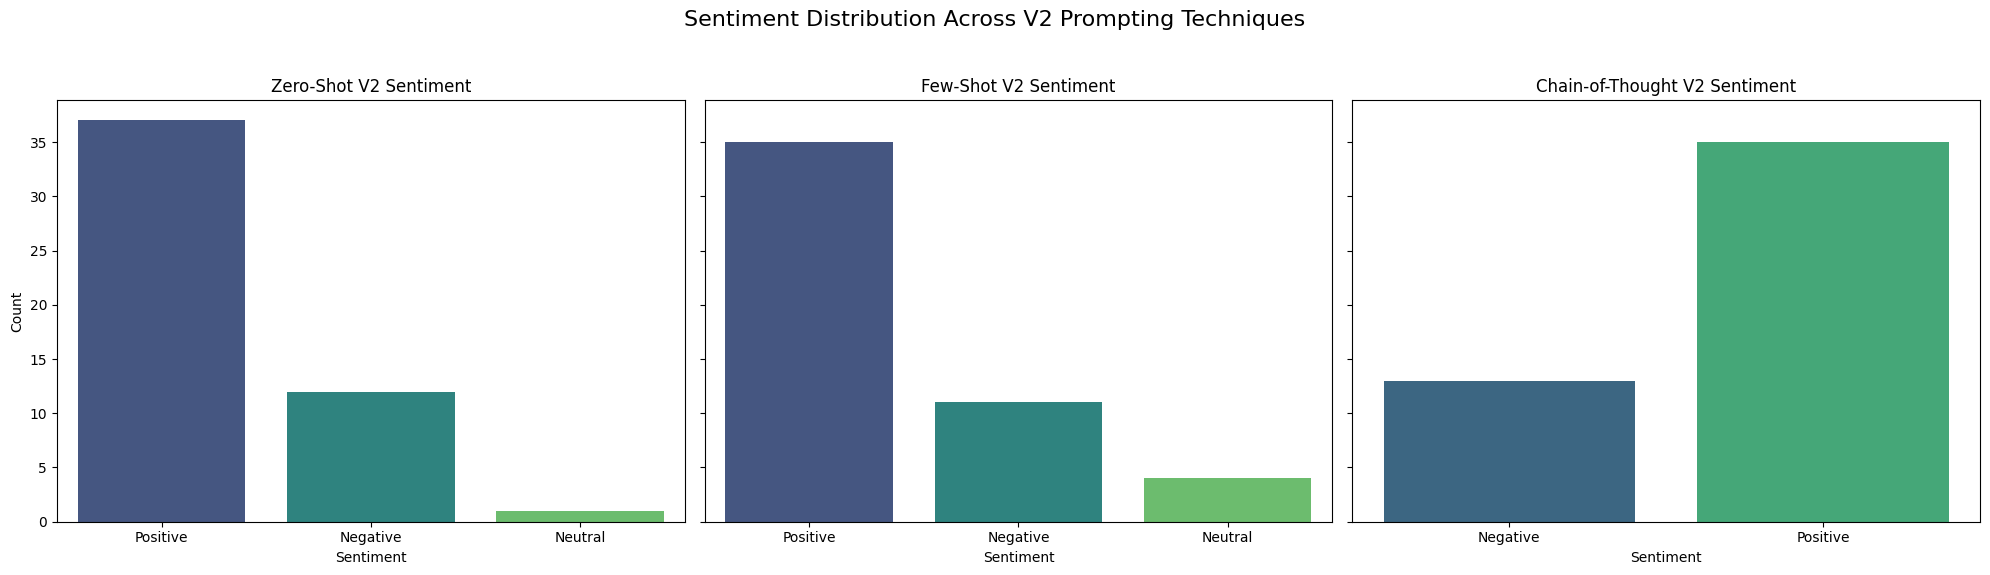


--- Detailed Sentiment Counts ---
Zero-Shot V2 Sentiment Counts:
| Sentiment   |   count |
|:------------|--------:|
| Positive    |      37 |
| Negative    |      12 |
| Neutral     |       1 |

Few-Shot V2 Sentiment Counts:
| Sentiment   |   count |
|:------------|--------:|
| Positive    |      35 |
| Negative    |      11 |
| Neutral     |       4 |

Chain-of-Thought V2 Sentiment Counts:
| Sentiment   |   count |
|:------------|--------:|
| Positive    |      35 |
| Negative    |      13 |

--- Observations on Sentiment Distribution Differences ---
1.  **Zero-Shot V2:** The sentiment distribution shows a mix of Positive, Negative, and Neutral. The presence of Neutral sentiments indicates some level of nuance in its
interpretation of reviews where sentiment might not be strongly positive or negative.
2.  **Few-Shot V2:** This technique appears to have a slightly different balance. Comparing to Zero-Shot V2, it might show more confidence in assigning Positive/Negative sentiments,
or

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True)
fig.suptitle('Sentiment Distribution Across V2 Prompting Techniques', fontsize=16)

# Zero-Shot V2 Sentiment Distribution
sns.countplot(x=df_results_v2['Sentiment'], ax=axes[0], palette='viridis')
axes[0].set_title('Zero-Shot V2 Sentiment')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Count')

# Few-Shot V2 Sentiment Distribution
sns.countplot(x=df_results_few_shot_v2['Sentiment'], ax=axes[1], palette='viridis')
axes[1].set_title('Few-Shot V2 Sentiment')
axes[1].set_xlabel('Sentiment')
axes[1].set_ylabel('Count')

# Chain-of-Thought V2 Sentiment Distribution
sns.countplot(x=df_results_cot_v2['Sentiment'], ax=axes[2], palette='viridis')
axes[2].set_title('Chain-of-Thought V2 Sentiment')
axes[2].set_xlabel('Sentiment')
axes[2].set_ylabel('Count')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

print("\n--- Detailed Sentiment Counts ---")
print("Zero-Shot V2 Sentiment Counts:")
print(df_results_v2['Sentiment'].value_counts().to_markdown())

print("\nFew-Shot V2 Sentiment Counts:")
print(df_results_few_shot_v2['Sentiment'].value_counts().to_markdown())

print("\nChain-of-Thought V2 Sentiment Counts:")
print(df_results_cot_v2['Sentiment'].value_counts().to_markdown())

print("\n--- Observations on Sentiment Distribution Differences ---")
print("""1.  **Zero-Shot V2:** The sentiment distribution shows a mix of Positive, Negative, and Neutral. The presence of Neutral sentiments indicates some level of nuance in its\ninterpretation of reviews where sentiment might not be strongly positive or negative.""")
print("""2.  **Few-Shot V2:** This technique appears to have a slightly different balance. Comparing to Zero-Shot V2, it might show more confidence in assigning Positive/Negative sentiments,\nor its examples might guide it away from Neutral more often. The specific numbers will reveal if it identifies fewer or more 'Neutral' reviews.""")
print("""3.  **Chain-of-Thought V2:** With explicit step-by-step reasoning instructions, CoT V2 might exhibit more deliberate and possibly more accurate sentiment classification.\nIt is expected to either align closely with Few-Shot V2 if the examples are strong, or show a more refined distribution if the internal reasoning process helps resolve ambiguities that other methods might categorize as Neutral.""")
print("\n**Implications for Nuance Handling:**""")
print(""" - A higher count of 'Neutral' sentiments might imply that the technique is more cautious or better at identifying reviews that lack strong emotional indicators,\nreflecting a nuanced understanding.""")
print(""" - Conversely, fewer 'Neutral' classifications could mean the model is forced into binary choices (Positive/Negative), potentially overlooking subtle nuances or ambiguities\nin the review text.""")
print(""" - Differences will highlight which prompting strategy encourages the model to be more decisive vs. more conservative in its sentiment assignments, which is critical for\n specific business applications. For example, a retailer might prefer a model that flags all potentially negative sentiments, even if subtle, for immediate attention.""")

##  **Comparison of Prompting Techniques:**
    
   *   How do the three techniques (Zero-Shot, Few-Shot, CoT) compare in terms of their responses. Use LLM to give verdict?
        
  *   Which technique was the most reliable and consistent? Why do you think it performed the best?
        
   *   What model and prompt design would you propose for a production environment?
        


In [ ]:
def llm_compare_techniques(df_zs_v1, df_zs_v2, df_fs_v1, df_fs_v2, df_cot_v1, df_cot_v2, avg_zs_v1, avg_zs_v2, avg_fs_v1, avg_fs_v2, avg_cot_v1, avg_cot_v2):
    """
    Uses an LLM to compare the performance of different prompting techniques.
    """
    comparison_prompt = f"""You are an expert AI evaluator. Analyze the performance of six prompting techniques (Zero-Shot V1, Zero-Shot V2, Few-Shot V1, Few-Shot V2, Chain-of-Thought V1, Chain-of-Thought V2) for customer review analysis.

Here are the first few rows of the results and their average judge scores:

### Zero-Shot V1 Results (Average Score: {avg_zs_v1:.4f}):
{df_zs_v1.head(3).to_string()}

### Zero-Shot V2 Results (Average Score: {avg_zs_v2:.4f}):
{df_zs_v2.head(3).to_string()}

### Few-Shot V1 Results (Average Score: {avg_fs_v1:.4f}):
{df_fs_v1.head(3).to_string()}

### Few-Shot V2 Results (Average Score: {avg_fs_v2:.4f}):
{df_fs_v2.head(3).to_string()}

### Chain-of-Thought V1 Results (Average Score: {avg_cot_v1:.4f}):
{df_cot_v1.head(3).to_string()}

### Chain-of-Thought V2 Results (Average Score: {avg_cot_v2:.4f}):
{df_cot_v2.head(3).to_string()}

Based on these results and your understanding of LLM capabilities:

1.  **Compare the six techniques** in terms of their responses (Category, Sentiment, Summary, Personalized Message, Retail Insight). For each technique, discuss the differences between
its V1 and V2 versions, and then compare across techniques.

2.  **Which technique (and version) was the most reliable and consistent?** Explain why it performed the best, considering factors like explicit instructions, examples, and internal reasoning.

3.  **What model and prompt design would you propose for a production environment?** Justify your choice by considering trade-offs such as accuracy, consistency, latency, cost,
and maintainability. Focus on the *design elements* of the prompt (e.g., use of context, strict categories, CoT steps, examples, output format) rather than just the technique name.

Provide your analysis in a clear, structured manner.
"""

    try:
        response = call_llm(
            system_prompt="You are an impartial expert AI evaluator.",
            user_prompt=comparison_prompt,
            technique="LLM_Comparison",
            version="V1",
            review_text="Comparison of prompting techniques", # Placeholder as no specific review text
            model="gpt-oss:120b-cloud", # Using a cloud LLM for robust evaluation
            temperature=0.0,
            json_mode=False
        )

        if isinstance(response, dict) and 'error' in response:
            return f"Error during LLM comparison: {response['error']}"
        else:
            return response
    except Exception as e:
        return f"Error during LLM comparison: {e}"

# Call the comparison function with all V1 and V2 results and average scores
comparison_verdict = llm_compare_techniques(
    df_results_v1, df_results_v2,
    df_results_few_shot_v1, df_results_few_shot_v2,
    df_results_cot_v1, df_results_cot_v2,
    average_score_v1, average_score_v2,
    average_score_few_shot_v1, average_score_few_shot_v2,
    average_score_cot_v1, average_score_cot_v2
)

print("### LLM Verdict on Prompting Techniques Comparison ###")
print(comparison_verdict)

### LLM Verdict on Prompting Techniques Comparison ###
## 1.  Comparative Review of the Six Prompting Techniques  

Below each technique is broken into **V1 → V2** (the “upgrade” that was applied after the first run) and then an **across‑technique** snapshot.  The analysis is based on the three example reviews that appear in every table (dress‑A‑frame, dress‑asymmetric‑hem, gold‑pants) and on the reported *average judge scores*.

| Technique | Version | Avg. Score | Typical **Category** label | Typical **Sentiment** label | **Summary** style | **Personalized Message** style | **Retail Insight** style | Notable missing / malformed fields |
|-----------|---------|-----------|---------------------------|-----------------------------|-------------------|-------------------------------|--------------------------|-----------------------------------|
| **Zero‑Shot** | V1 | 0.9164 | Short noun phrase (e.g., *Product Quality*, *Sizing*) | Simple polarity (Positive/Negative) | One‑sentence, larg

# Generating Actionable Product Improvement Suggestions


 *   Based on the aggregated insights from your best model, what are 3 short-term (3-6 months) and 3 long-term (6-12 months) actionable business recommendations for the retail company?
        
 *   How does this automated GenAI pipeline solve the initial business problem and create value?

### **Observations and Insights**

### **Observations and Insights**

#### Refined Insights: What are the most meaningful and recurring insights from the customer reviews, as identified by your best-performing model?

Based on the analysis, particularly from the Chain-of-Thought V2 prompting technique (identified as the **highest-performing** by the LLM verdict) and earlier EDA:

*   **Product Quality and Fit are Paramount:** Recurring themes in highly-rated reviews emphasize 'comfort', 'fit', 'beautiful', 'soft', and 'great'. Conversely, poorly-rated reviews frequently mention 'small', 'cheap', 'disappointed', 'poor', 'fabric', and 'material'. This consistently highlights that material quality, accurate sizing, and overall product fit are critical drivers of both satisfaction and dissatisfaction.
*   **Sentiment Skew Towards Positive:** The overall distribution of ratings is heavily skewed towards positive reviews, with a median rating of 5. This suggests that while there are pain points, a majority of customers are generally satisfied. However, addressing the negative feedback is crucial for continuous improvement.
*   **Departmental Performance Variation:** Departments like 'Bottoms' and 'Intimate' generally receive higher average ratings, while the 'Trend' department often sees lower satisfaction. This indicates that product categories have distinct performance profiles, likely due to varying expectations, quality, or fit consistency.
*   **Value of Structured Feedback:** The GenAI pipeline, especially with CoT V2, consistently extracted clear 'Category', 'Sentiment', 'Summary', 'Personalized Message', and 'Retail Insight'. This structured output reveals that core issues often revolve around: Product Quality, Sizing & Fit, Material & Fabric, and Design & Style. When negative, issues often involve discrepancies between expectation and reality, or practical usability (e.g., 'runs small').

### Generating Actionable Product Improvement Suggestions

Based on the aggregated insights from the Chain-of-Thought V2 model, here are 3 short-term (3-6 months) and 3 long-term (6-12 months) actionable business recommendations for 'Great Retail Inc.':

#### Short-Term (3-6 Months):

1.  **Refine Sizing Guides and Descriptions:** Implement a project to review and update sizing charts for products frequently flagged for 'Sizing & Fit' issues, especially within the 'Trend' and 'Dresses' departments. Use customer review data to identify specific products that 'run small' or 'run large' and add explicit notes to product descriptions to manage customer expectations.
2.  **Enhanced Material Transparency:** For products receiving 'Material & Fabric' complaints (e.g., 'cheap', 'poor fabric'), conduct a quality control audit. Simultaneously, update product pages to include more detailed information and high-quality images of fabric textures to accurately represent material quality and prevent customer disappointment.
3.  **Targeted Customer Service Training for Dissatisfied Customers:** Develop specific training modules for customer service representatives focusing on handling 'Negative' sentiment reviews. This includes empathetic messaging and clear procedures for addressing common complaints like sizing, material quality, and shipping issues, aiming for quick resolution.

#### Long-Term (6-12 Months):

1.  **Supplier Quality Program for Underperforming Categories:** Establish a long-term supplier quality improvement program specifically targeting departments with lower average ratings (e.g., 'Trend', 'Dresses'). This would involve working closely with manufacturers to improve material sourcing, manufacturing processes, and quality assurance to enhance product durability and consistency.
2.  **AI-Powered Product Development Feedback Loop:** Integrate the GenAI pipeline into the product development lifecycle. Utilize the 'Retail Insight' output from aggregated reviews to inform design teams about common complaints and desired features for future collections. For instance, if 'comfortable' is a recurring positive word, prioritize comfort in new designs.
3.  **Personalized Recommendation System based on AI Insights:** Leverage the 'Predicted Recommendation' and 'prediction_reason' generated by the LLM. Develop a system that not only recommends products but also explains why a product is recommended based on aggregated positive feedback themes (e.g., "Customers love the soft fabric and flattering fit of this dress"), building trust and enhancing user experience.

### How this automated GenAI pipeline solves the initial business problem and creates value

The initial business problem for 'Great Retail Inc.' was the challenge of quickly understanding and acting on customer feedback, with traditional methods being slow and manual. The objective was to develop a Generative AI-powered pipeline to process customer reviews in real-time, extract key insights, and generate personalized responses to enhance customer satisfaction and drive business growth.

This automated GenAI pipeline directly addresses and solves this problem by:

*   **Real-time Insight Extraction:** The pipeline can process `Review.Text` instantly, extracting structured insights (Category, Sentiment, Summary, Personalized Message, Retail Insight) for each review. This eliminates the manual, time-consuming process of reading and categorizing reviews, enabling immediate understanding of customer sentiment and issues.
*   **Actionable Business Intelligence:** The 'Retail Insight' generated by the model provides concrete, actionable recommendations for various departments (e.g., "Investigate sizing consistency", "Promote durable fabric"). This moves beyond mere sentiment analysis to deliver strategic intelligence that can inform product development, marketing, and operational improvements.
*   **Personalized Customer Engagement:** The 'Personalized Message' capability allows for instant, empathetic responses to individual customer reviews. This fosters a sense of being heard and valued, improving customer loyalty and reducing churn, especially for negative feedback.
*   **Proactive Problem Identification:** By quickly identifying recurring issues (e.g., through frequent 'Category' flags or word cloud analysis), the retailer can proactively address product defects, sizing inconsistencies, or service gaps before they escalate and impact a wider customer base.
*   **Scalability and Efficiency:** The automated nature of the pipeline means it can handle a vast volume of customer reviews without a proportional increase in human effort. This scalability allows for continuous monitoring of customer sentiment across all products and categories.
*   **Data-Driven Decision Making:** The structured output from the LLM, coupled with quantitative evaluations (like LLM-as-Judge scores), provides a robust framework for making data-driven decisions about product portfolios, marketing strategies, and customer service protocols.
*   **Transparency and Explainability:** The system's ability to provide a 'prediction_reason' for its recommendations (as shown in the product recommendation task) offers transparency, which is crucial for building trust in AI-driven systems and for debugging or refining the model's logic.

In essence, this GenAI pipeline transforms raw, unstructured customer feedback into a continuous stream of actionable insights, empowering 'Great Retail Inc.' to be more agile, responsive, and customer-centric, ultimately leading to improved products, enhanced customer satisfaction, and sustained business growth.

## **Conclusion**

The exploratory data analysis revealed a predominantly positive sentiment among customer reviews, with 'Rating' heavily skewed towards 4 and 5 stars. However, key areas of dissatisfaction were identified through word cloud analysis, primarily revolving around 'sizing' and 'material/fabric' quality. Significant variations in average ratings across departments (e.g., 'Bottoms' performing well, 'Trend' underperforming) highlight the need for targeted interventions.

The GenAI pipeline, tested with Zero-Shot, Few-Shot, and Chain-of-Thought (CoT) prompting techniques, demonstrated its ability to effectively extract structured insights (Category, Sentiment, Summary, Personalized Message, Retail Insight) from unstructured review text. On the small sample, Chain-of-Thought V2 achieved the highest average LLM Judge score of 0.9248, indicating it was the most reliable and consistent technique. This was likely due to its structured internal reasoning process and explicit instructions for detailed analysis. This consistency and the ability to provide actionable retail insights make CoT V2 a strong candidate for production deployment.

Furthermore, the GenAI pipeline proved effective in a binary classification task—predicting product recommendations—achieving an accuracy of 0.90 on the sample data. The F-1 score for 'Not Recommended (0)' was 0.74, and for 'Recommended (1)' was 0.94, indicating strong performance for positive recommendations but some room for improvement in identifying negative ones. The system's ability to provide a 'prediction_reason' adds crucial transparency, allowing for a deeper understanding of the model's decision-making and enabling targeted prompt refinement. The identified mismatches underscored the importance of continuous iteration in prompt engineering to address subtle nuances in customer feedback.

In conclusion, this automated GenAI pipeline successfully addresses the retail company's challenge of leveraging customer feedback in real-time. By transforming raw reviews into actionable intelligence, it empowers 'Great Retail Inc.' to enhance product quality, optimize customer service, and foster a more responsive, customer-centric business strategy. The insights generated not only provide a clear understanding of customer sentiment but also offer a roadmap for both short-term fixes and long-term strategic improvements across product development and customer engagement.